---
## 1. Setup and Data Loading

In [44]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy import stats
import sys
!{sys.executable} -m pip install scipy scikit-learn
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 8)
plt.rcParams['font.size'] = 10

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


'c:\Users\icon\Downloads\Project' is not recognized as an internal or external command,
operable program or batch file.


In [45]:
import sys
print(sys.executable)


c:\Users\icon\Downloads\Project 1\Project 1\my_project\venv\Scripts\python.exe


In [3]:
# Load dataset
# TODO: Update the filepath to your actual CSV file location
df = pd.read_csv("cybersecurity_attacks.csv")

print(f"Dataset Shape: {df.shape}")
print(f"Total Records: {df.shape[0]:,}")
print(f"Total Features: {df.shape[1]}")

Dataset Shape: (40000, 25)
Total Records: 40,000
Total Features: 25


In [4]:
# Display first few rows
df.head()

,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Payload Data,...,Action Taken,Severity Level,User Information,Device Information,Network Segment,Geo-location Data,Proxy Information,Firewall Logs,IDS/IPS Alerts,Log Source
0,2023-05-30 06:33:58,103.216.15.12,84.9.164.252,31225,17616,ICMP,503,Data,HTTP,Qui natus odio asperiores nam. Optio nobis ius...,...,Logged,Low,Reyansh Dugal,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment A,"Jamshedpur, Sikkim",150.9.97.135,Log Data,NaN,Server
1,2020-08-26 07:08:30,78.199.217.198,66.191.137.154,17245,48166,ICMP,1174,Data,HTTP,Aperiam quos modi officiis veritatis rem. Omni...,...,Blocked,Low,Sumer Rana,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment B,"Bilaspur, Nagaland",NaN,Log Data,NaN,Firewall
2,2022-11-13 08:23:25,63.79.210.48,198.219.82.17,16811,53600,UDP,306,Control,HTTP,Perferendis sapiente vitae soluta. Hic delectu...,...,Ignored,Low,Himmat Karpe,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,Segment C,"Bokaro, Rajasthan",114.133.48.179,Log Data,Alert Data,Firewall
3,2023-07-02 10:38:46,163.42.196.10,101.228.192.255,20018,32534,UDP,385,Data,HTTP,Totam maxime beatae expedita explicabo porro l...,...,Blocked,Medium,Fateh Kibe,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_11_5; ...,Segment B,"Jaunpur, Rajasthan",NaN,NaN,Alert Data,Firewall
4,2023-07-16 13:11:07,71.166.185.76,189.243.174.238,6131,26646,TCP,1462,Data,DNS,Odit nesciunt dolorem nisi iste iusto. Animi v...,...,Blocked,Low,Dhanush Chad,Mozilla/5.0 (compatible; MSIE 5.0; Windows NT ...,Segment C,"Anantapur, Tripura",149.6.110.119,NaN,Alert Data,Firewall


In [5]:
# Data types and basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               40000 non-null  object 
 1   Source IP Address       40000 non-null  object 
 2   Destination IP Address  40000 non-null  object 
 3   Source Port             40000 non-null  int64  
 4   Destination Port        40000 non-null  int64  
 5   Protocol                40000 non-null  object 
 6   Packet Length           40000 non-null  int64  
 7   Packet Type             40000 non-null  object 
 8   Traffic Type            40000 non-null  object 
 9   Payload Data            40000 non-null  object 
 10  Malware Indicators      20000 non-null  object 
 11  Anomaly Scores          40000 non-null  float64
 12  Alerts/Warnings         19933 non-null  object 
 13  Attack Type             40000 non-null  object 
 14  Attack Signature        40000 non-null

In [6]:
# Missing values analysis
missing_df = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Percentage': (df.isnull().sum() / len(df)) * 100,
    'Distinct_Count': df.nunique(),
    'Distinct_Percentage': (df.nunique() / len(df)) * 100
}).sort_values('Missing_Count', ascending=False)

print("\n" + "="*80)
print("MISSING VALUES AND DISTINCTNESS ANALYSIS")
print("="*80)
print(missing_df)


MISSING VALUES AND DISTINCTNESS ANALYSIS
                        Missing_Count  Percentage  Distinct_Count  \
Alerts/Warnings                 20067     50.1675               1   
IDS/IPS Alerts                  20050     50.1250               1   
Malware Indicators              20000     50.0000               1   
Firewall Logs                   19961     49.9025               1   
Proxy Information               19851     49.6275           20148   
Source IP Address                   0      0.0000           40000   
Destination IP Address              0      0.0000           40000   
Source Port                         0      0.0000           29761   
Timestamp                           0      0.0000           39997   
Traffic Type                        0      0.0000               3   
Packet Type                         0      0.0000               2   
Packet Length                       0      0.0000            1437   
Protocol                            0      0.0000            


Attack Type Distribution:
Attack Type
DDoS         13428
Malware      13307
Intrusion    13265
Name: count, dtype: int64


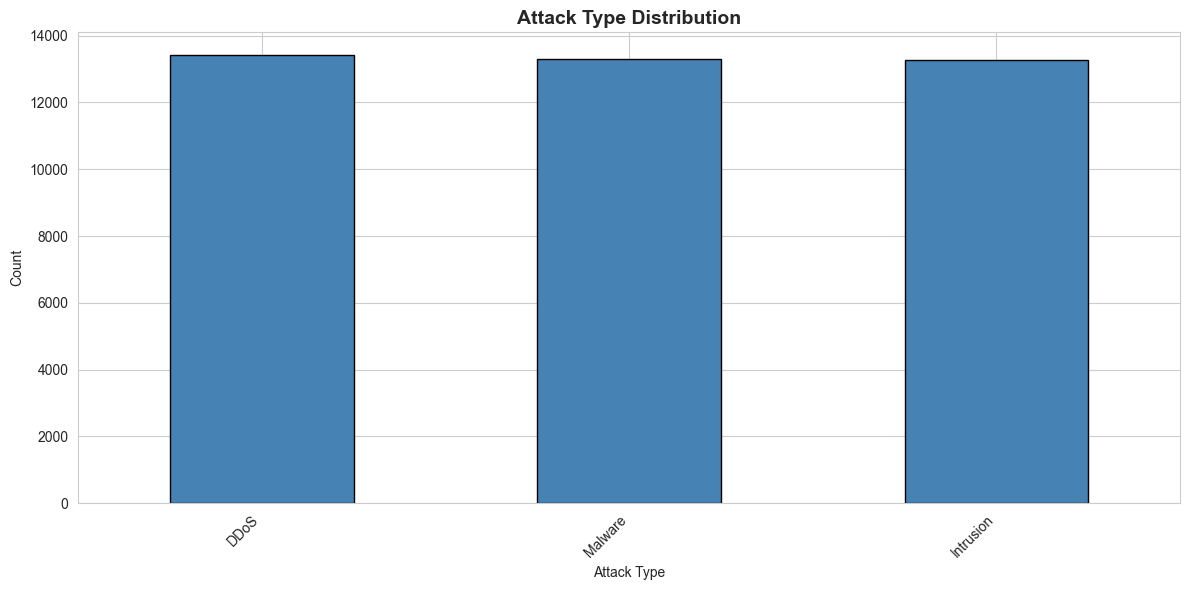

In [7]:
# Attack Type distribution
if 'Attack Type' in df.columns:
    print("\nAttack Type Distribution:")
    print(df['Attack Type'].value_counts())
    
    plt.figure(figsize=(12, 6))
    df['Attack Type'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
    plt.title('Attack Type Distribution', fontsize=14, fontweight='bold')
    plt.xlabel('Attack Type')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

---
## 2. PART 1: Proxy Information Analysis

In [59]:
# Proxy Information Analysis
print("="*80)
print("PROXY INFORMATION ANALYSIS")
print("="*80)

if 'Proxy Information' in df.columns:
    # Basic statistics
    total_records = len(df)
    proxy_present = df['Proxy Information'].notna().sum()
    proxy_missing = df['Proxy Information'].isna().sum()
    unique_proxies = df['Proxy Information'].nunique()
    
    print(f"\nProxy Information Statistics:")
    print(f"  - Total records: {total_records:,}")
    print(f"  - Records WITH proxy info: {proxy_present:,} ({proxy_present/total_records*100:.2f}%)")
    print(f"  - Records WITHOUT proxy info: {proxy_missing:,} ({proxy_missing/total_records*100:.2f}%)")
    print(f"  - Unique proxy values: {unique_proxies:,}")
    
    # Create binary feature: has_proxy
    df['has_proxy'] = df['Proxy Information'].notna().astype(int)
    
    print(f"\nProxy Usage Distribution:")
    print(df['has_proxy'].value_counts())
else:
    print("Warning: 'Proxy Information' column not found!")

PROXY INFORMATION ANALYSIS

Proxy Information Statistics:
  - Total records: 40,000
  - Records WITH proxy info: 20,149 (50.37%)
  - Records WITHOUT proxy info: 19,851 (49.63%)
  - Unique proxy values: 20,148

Proxy Usage Distribution:
has_proxy
1    20149
0    19851
Name: count, dtype: int64



Proxy Usage by Attack Type:
has_proxy            0          1
Attack Type                      
DDoS         49.471254  50.528746
Intrusion    50.267622  49.732378
Malware      49.147065  50.852935


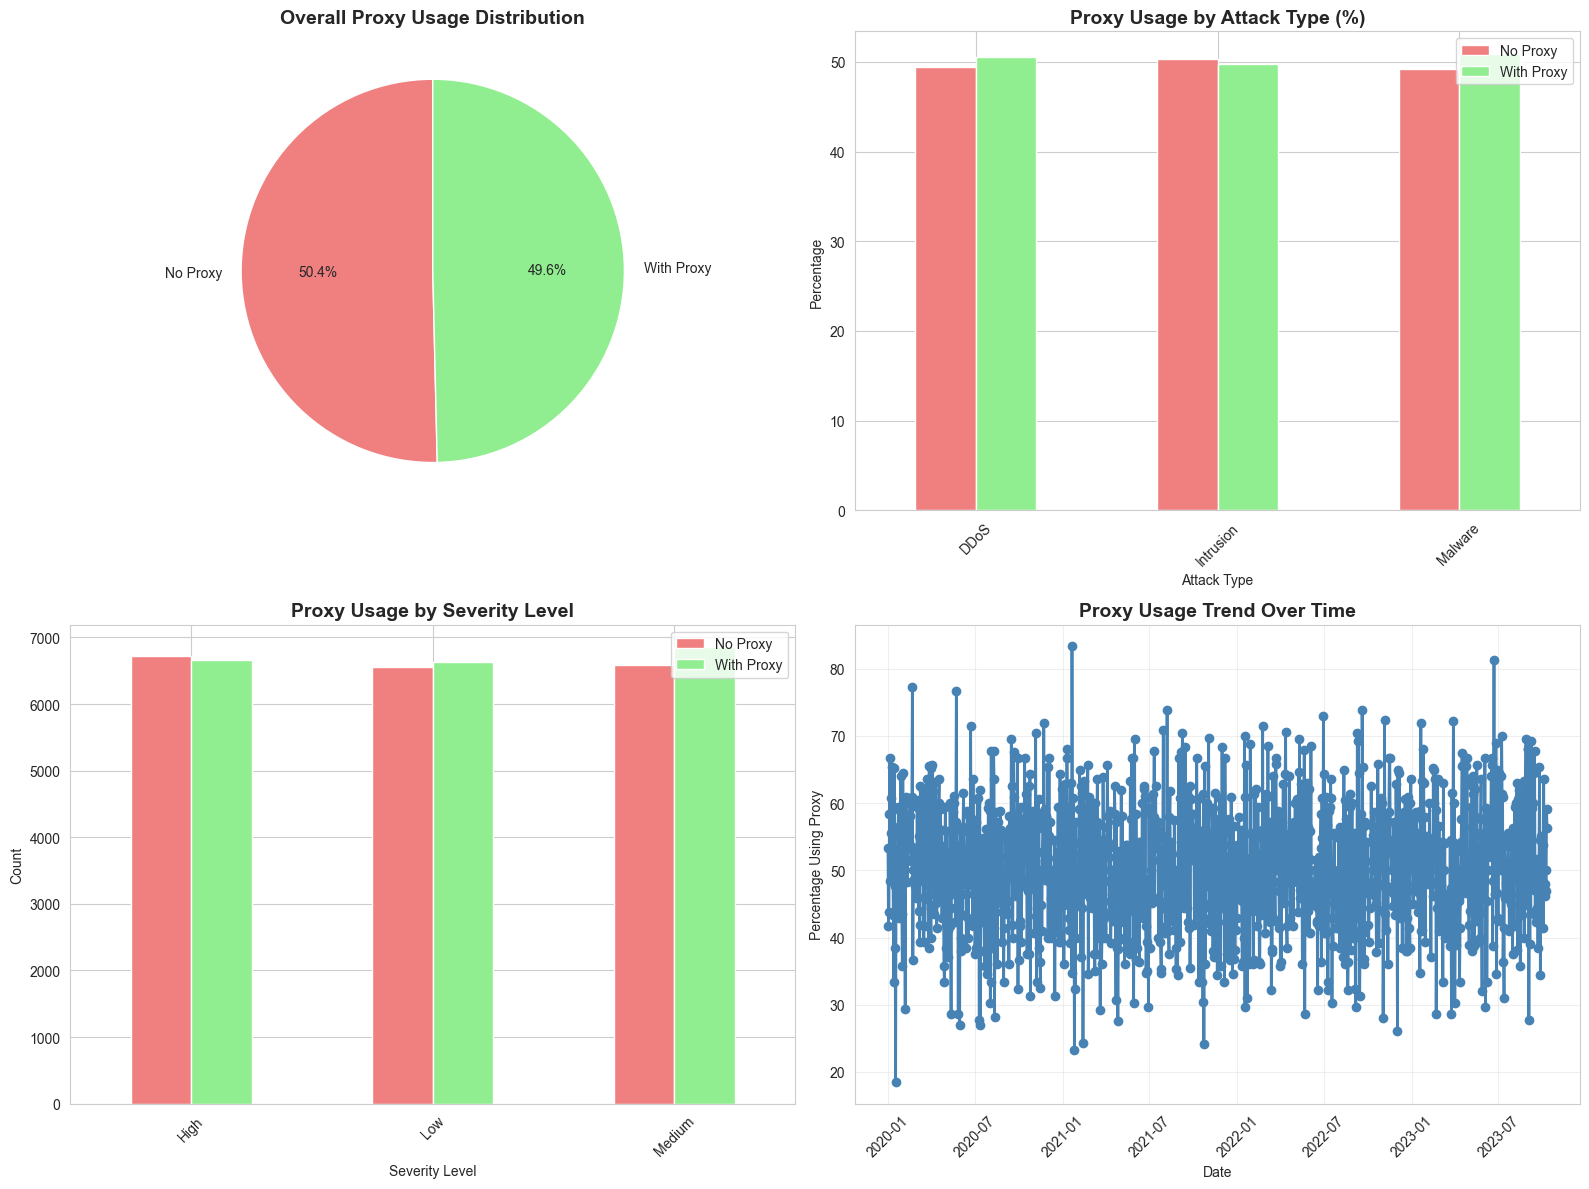

In [60]:
# Visualize proxy usage patterns
if 'has_proxy' in df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Overall proxy usage pie chart
    proxy_counts = df['has_proxy'].value_counts()
    labels = ['No Proxy', 'With Proxy']
    colors = ['lightcoral', 'lightgreen']
    axes[0, 0].pie(proxy_counts.values, labels=labels, autopct='%1.1f%%', 
                    colors=colors, startangle=90)
    axes[0, 0].set_title('Overall Proxy Usage Distribution', fontsize=14, fontweight='bold')
    
    # 2. Proxy usage by Attack Type
    if 'Attack Type' in df.columns:
        proxy_attack = pd.crosstab(df['Attack Type'], df['has_proxy'], normalize='index') * 100
        proxy_attack.plot(kind='bar', ax=axes[0, 1], stacked=False, 
                         color=['lightcoral', 'lightgreen'])
        axes[0, 1].set_title('Proxy Usage by Attack Type (%)', fontsize=14, fontweight='bold')
        axes[0, 1].set_xlabel('Attack Type')
        axes[0, 1].set_ylabel('Percentage')
        axes[0, 1].legend(['No Proxy', 'With Proxy'])
        axes[0, 1].tick_params(axis='x', rotation=45)
        
        # Print statistical summary
        print("\nProxy Usage by Attack Type:")
        print(proxy_attack)
    
    # 3. Proxy usage by Severity Level
    if 'Severity Level' in df.columns:
        proxy_severity = pd.crosstab(df['Severity Level'], df['has_proxy'])
        proxy_severity.plot(kind='bar', ax=axes[1, 0], color=['lightcoral', 'lightgreen'])
        axes[1, 0].set_title('Proxy Usage by Severity Level', fontsize=14, fontweight='bold')
        axes[1, 0].set_xlabel('Severity Level')
        axes[1, 0].set_ylabel('Count')
        axes[1, 0].legend(['No Proxy', 'With Proxy'])
        axes[1, 0].tick_params(axis='x', rotation=45)
    
    # 4. Proxy usage over time
    if 'Timestamp' in df.columns:
        df_temp = df.copy()
        df_temp['Timestamp'] = pd.to_datetime(df_temp['Timestamp'], errors='coerce')
        df_temp = df_temp.dropna(subset=['Timestamp'])
        df_temp['Date'] = df_temp['Timestamp'].dt.date
        
        proxy_time = df_temp.groupby('Date')['has_proxy'].agg(['sum', 'count'])
        proxy_time['percentage'] = (proxy_time['sum'] / proxy_time['count']) * 100
        
        axes[1, 1].plot(proxy_time.index, proxy_time['percentage'], 
                       marker='o', color='steelblue', linewidth=2)
        axes[1, 1].set_title('Proxy Usage Trend Over Time', fontsize=14, fontweight='bold')
        axes[1, 1].set_xlabel('Date')
        axes[1, 1].set_ylabel('Percentage Using Proxy')
        axes[1, 1].tick_params(axis='x', rotation=45)
        axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


Proxy Usage by Log Source:
has_proxy           0          1
Log Source                      
Firewall    49.482999  50.517001
Server      49.773687  50.226313


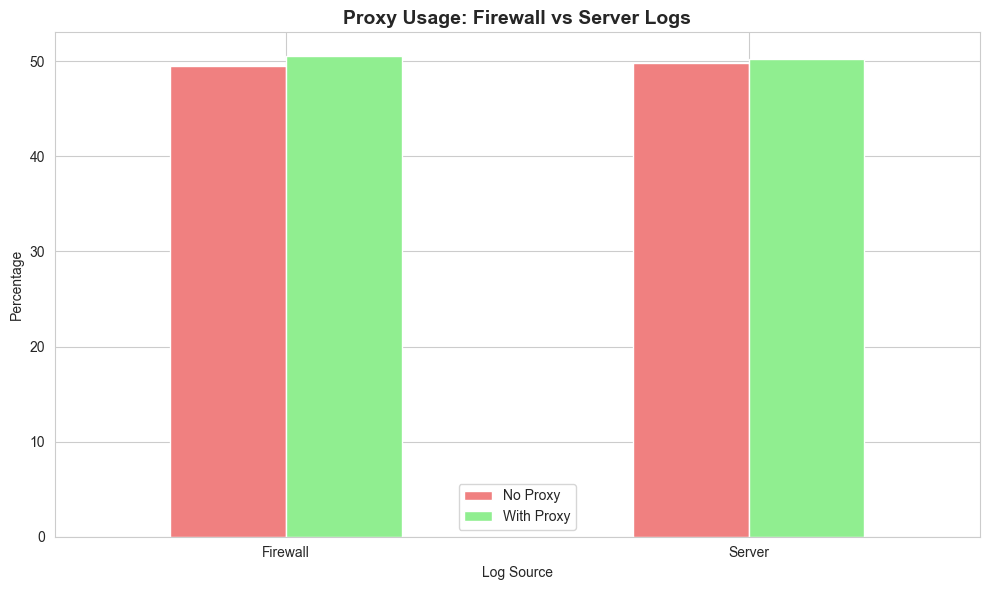

In [61]:
# Analyze relationship with Log Source (Firewall vs Server)
if 'Log Source' in df.columns and 'has_proxy' in df.columns:
    print("\nProxy Usage by Log Source:")
    log_proxy = pd.crosstab(df['Log Source'], df['has_proxy'], normalize='index') * 100
    print(log_proxy)
    
    # Visualize
    log_proxy.plot(kind='bar', figsize=(10, 6), color=['lightcoral', 'lightgreen'])
    plt.title('Proxy Usage: Firewall vs Server Logs', fontsize=14, fontweight='bold')
    plt.xlabel('Log Source')
    plt.ylabel('Percentage')
    plt.legend(['No Proxy', 'With Proxy'])
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [62]:
# Statistical significance test
if 'Attack Type' in df.columns and 'has_proxy' in df.columns:
    print("\n" + "="*80)
    print("PROXY USAGE INSIGHTS BY ATTACK TYPE")
    print("="*80)
    
    for attack_type in df['Attack Type'].unique():
        subset = df[df['Attack Type'] == attack_type]
        proxy_pct = (subset['has_proxy'].sum() / len(subset)) * 100
        
        print(f"\n{attack_type}:")
        print(f"  - Total attacks: {len(subset):,}")
        print(f"  - With proxy: {subset['has_proxy'].sum():,} ({proxy_pct:.2f}%)")
        print(f"  - Without proxy: {len(subset) - subset['has_proxy'].sum():,} ({100-proxy_pct:.2f}%)")


PROXY USAGE INSIGHTS BY ATTACK TYPE

Malware:
  - Total attacks: 13,307
  - With proxy: 6,767 (50.85%)
  - Without proxy: 6,540 (49.15%)

DDoS:
  - Total attacks: 13,428
  - With proxy: 6,785 (50.53%)
  - Without proxy: 6,643 (49.47%)

Intrusion:
  - Total attacks: 13,265
  - With proxy: 6,597 (49.73%)
  - Without proxy: 6,668 (50.27%)


---
## 3. PART 2: IP Trends and Spoofing Detection

In [12]:
print("="*80)
print("IP TRENDS AND SPOOFING DETECTION")
print("="*80)

# Basic IP statistics
if 'Source IP Address' in df.columns and 'Destination IP Address' in df.columns:
    print(f"\nIP Address Statistics:")
    print(f"  - Unique Source IPs: {df['Source IP Address'].nunique():,}")
    print(f"  - Unique Destination IPs: {df['Destination IP Address'].nunique():,}")
    print(f"  - Total IP-to-IP connections: {len(df):,}")
    print(f"  - Average connections per source IP: {len(df)/df['Source IP Address'].nunique():.2f}")
    print(f"  - Average connections per destination IP: {len(df)/df['Destination IP Address'].nunique():.2f}")

IP TRENDS AND SPOOFING DETECTION

IP Address Statistics:
  - Unique Source IPs: 40,000
  - Unique Destination IPs: 40,000
  - Total IP-to-IP connections: 40,000
  - Average connections per source IP: 1.00
  - Average connections per destination IP: 1.00



TOP SOURCE IP ADDRESSES

Top 20 Source IPs:
Source IP Address
103.216.15.12      1
78.199.217.198     1
63.79.210.48       1
163.42.196.10      1
71.166.185.76      1
198.102.5.160      1
97.253.103.59      1
11.48.99.245       1
49.32.208.167      1
114.109.149.113    1
177.21.83.200      1
92.4.25.171        1
57.91.207.84       1
80.28.21.123       1
54.163.130.178     1
130.163.192.252    1
4.255.187.165      1
212.164.196.41     1
119.101.120.119    1
104.176.150.78     1
Name: count, dtype: int64


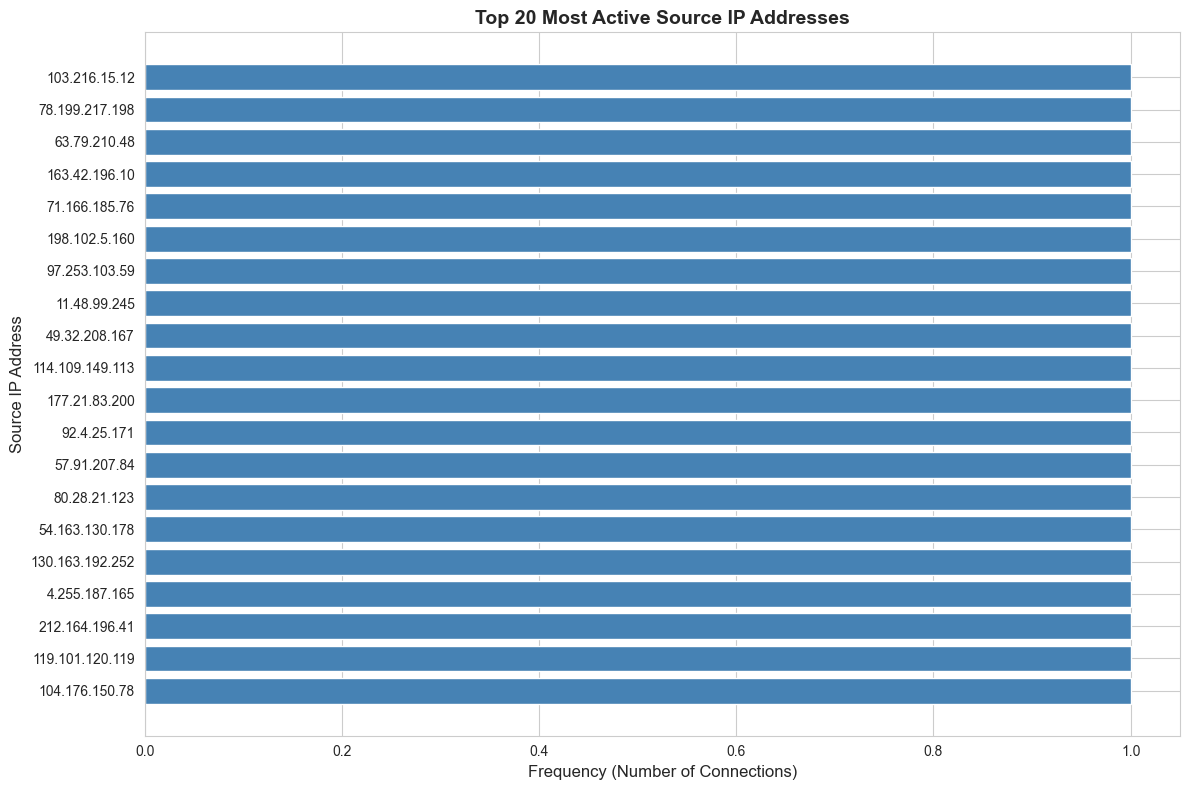

In [13]:
# Top Source IPs
print("\n" + "="*80)
print("TOP SOURCE IP ADDRESSES")
print("="*80)

top_src_ips = df['Source IP Address'].value_counts().head(20)
print("\nTop 20 Source IPs:")
print(top_src_ips)

# Visualize
plt.figure(figsize=(12, 8))
plt.barh(range(len(top_src_ips)), top_src_ips.values, color='steelblue')
plt.yticks(range(len(top_src_ips)), top_src_ips.index)
plt.xlabel('Frequency (Number of Connections)', fontsize=12)
plt.ylabel('Source IP Address', fontsize=12)
plt.title('Top 20 Most Active Source IP Addresses', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


TOP DESTINATION IP ADDRESSES

Top 20 Destination IPs:
Destination IP Address
84.9.164.252       1
66.191.137.154     1
198.219.82.17      1
101.228.192.255    1
189.243.174.238    1
147.190.155.133    1
77.16.101.53       1
178.157.14.116     1
72.202.237.9       1
160.88.194.172     1
196.218.124.169    1
112.43.185.24      1
98.96.110.38       1
111.204.103.106    1
62.112.149.214     1
12.192.2.112       1
136.159.186.239    1
32.26.31.49        1
47.125.34.52       1
110.80.185.102     1
Name: count, dtype: int64


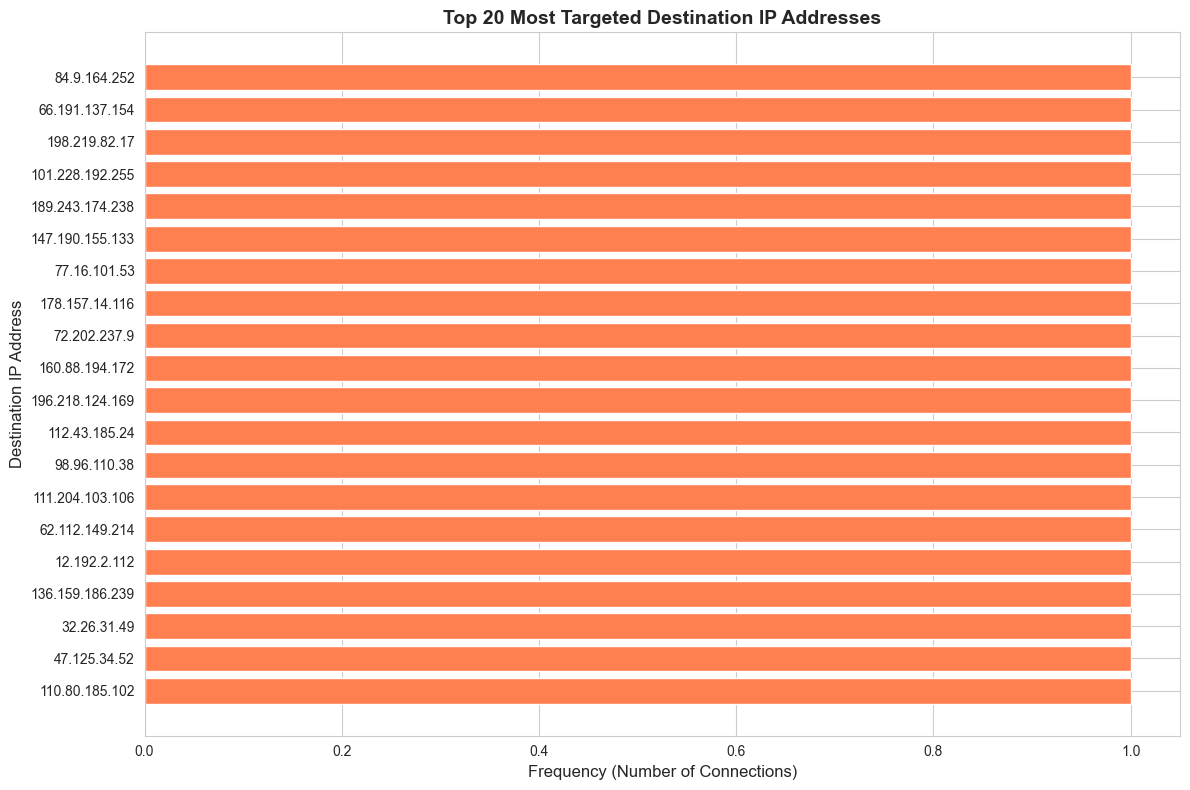

In [14]:
# Top Destination IPs
print("\n" + "="*80)
print("TOP DESTINATION IP ADDRESSES")
print("="*80)

top_dst_ips = df['Destination IP Address'].value_counts().head(20)
print("\nTop 20 Destination IPs:")
print(top_dst_ips)

# Visualize
plt.figure(figsize=(12, 8))
plt.barh(range(len(top_dst_ips)), top_dst_ips.values, color='coral')
plt.yticks(range(len(top_dst_ips)), top_dst_ips.index)
plt.xlabel('Frequency (Number of Connections)', fontsize=12)
plt.ylabel('Destination IP Address', fontsize=12)
plt.title('Top 20 Most Targeted Destination IP Addresses', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [15]:
# SPOOFING DETECTION 1: Fan-out Analysis (Source IP → Multiple Destinations)
print("\n" + "="*80)
print("SPOOFING INDICATOR 1: FAN-OUT PATTERN (Source → Multiple Destinations)")
print("="*80)

# Count unique destinations per source IP
src_to_dst_mapping = df.groupby('Source IP Address')['Destination IP Address'].nunique()
src_to_dst_mapping = src_to_dst_mapping.sort_values(ascending=False)

# Calculate thresholds
threshold_95 = src_to_dst_mapping.quantile(0.95)
threshold_99 = src_to_dst_mapping.quantile(0.99)

suspicious_sources_95 = src_to_dst_mapping[src_to_dst_mapping > threshold_95]
suspicious_sources_99 = src_to_dst_mapping[src_to_dst_mapping > threshold_99]

print(f"\nFan-out Statistics:")
print(f"  - Mean destinations per source: {src_to_dst_mapping.mean():.2f}")
print(f"  - Median destinations per source: {src_to_dst_mapping.median():.2f}")
print(f"  - 95th percentile threshold: {threshold_95:.0f} destinations")
print(f"  - 99th percentile threshold: {threshold_99:.0f} destinations")
print(f"\nSuspicious Source IPs:")
print(f"  - IPs above 95th percentile: {len(suspicious_sources_95)} ({len(suspicious_sources_95)/len(src_to_dst_mapping)*100:.2f}%)")
print(f"  - IPs above 99th percentile: {len(suspicious_sources_99)} ({len(suspicious_sources_99)/len(src_to_dst_mapping)*100:.2f}%)")

print(f"\nTop 10 Source IPs with Highest Fan-out:")
print(src_to_dst_mapping.head(10))


SPOOFING INDICATOR 1: FAN-OUT PATTERN (Source → Multiple Destinations)

Fan-out Statistics:
  - Mean destinations per source: 1.00
  - Median destinations per source: 1.00
  - 95th percentile threshold: 1 destinations
  - 99th percentile threshold: 1 destinations

Suspicious Source IPs:
  - IPs above 95th percentile: 0 (0.00%)
  - IPs above 99th percentile: 0 (0.00%)

Top 10 Source IPs with Highest Fan-out:
Source IP Address
1.1.45.194       1
1.1.51.229       1
1.10.201.206     1
1.10.74.49       1
1.100.115.5      1
1.101.138.199    1
1.103.126.230    1
1.103.203.179    1
1.105.131.117    1
1.106.4.163      1
Name: Destination IP Address, dtype: int64


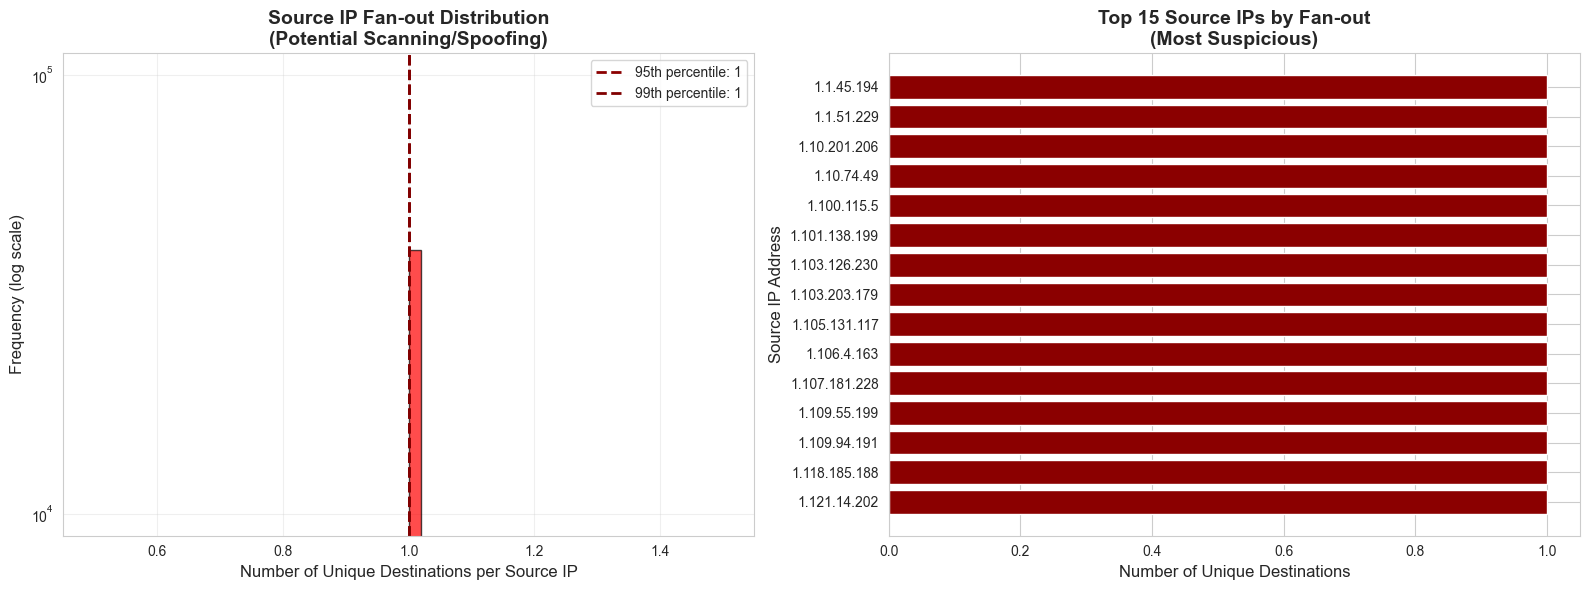

In [16]:
# Visualize fan-out distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
axes[0].hist(src_to_dst_mapping.values, bins=50, color='red', alpha=0.7, edgecolor='black')
axes[0].axvline(threshold_95, color='darkred', linestyle='--', linewidth=2, 
                label=f'95th percentile: {threshold_95:.0f}')
axes[0].axvline(threshold_99, color='maroon', linestyle='--', linewidth=2, 
                label=f'99th percentile: {threshold_99:.0f}')
axes[0].set_xlabel('Number of Unique Destinations per Source IP', fontsize=12)
axes[0].set_ylabel('Frequency (log scale)', fontsize=12)
axes[0].set_title('Source IP Fan-out Distribution\n(Potential Scanning/Spoofing)', 
                  fontsize=14, fontweight='bold')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Top suspicious IPs
top_suspicious = src_to_dst_mapping.head(15)
axes[1].barh(range(len(top_suspicious)), top_suspicious.values, color='darkred')
axes[1].set_yticks(range(len(top_suspicious)))
axes[1].set_yticklabels(top_suspicious.index)
axes[1].set_xlabel('Number of Unique Destinations', fontsize=12)
axes[1].set_ylabel('Source IP Address', fontsize=12)
axes[1].set_title('Top 15 Source IPs by Fan-out\n(Most Suspicious)', 
                  fontsize=14, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [17]:
# SPOOFING DETECTION 2: Fan-in Analysis (Multiple Sources → Single Destination)
print("\n" + "="*80)
print("SPOOFING INDICATOR 2: FAN-IN PATTERN (Multiple Sources → Destination)")
print("="*80)

# Count unique sources per destination IP
dst_to_src_mapping = df.groupby('Destination IP Address')['Source IP Address'].nunique()
dst_to_src_mapping = dst_to_src_mapping.sort_values(ascending=False)

# Calculate thresholds
threshold_95_dst = dst_to_src_mapping.quantile(0.95)
threshold_99_dst = dst_to_src_mapping.quantile(0.99)

suspicious_targets_95 = dst_to_src_mapping[dst_to_src_mapping > threshold_95_dst]
suspicious_targets_99 = dst_to_src_mapping[dst_to_src_mapping > threshold_99_dst]

print(f"\nFan-in Statistics:")
print(f"  - Mean sources per destination: {dst_to_src_mapping.mean():.2f}")
print(f"  - Median sources per destination: {dst_to_src_mapping.median():.2f}")
print(f"  - 95th percentile threshold: {threshold_95_dst:.0f} sources")
print(f"  - 99th percentile threshold: {threshold_99_dst:.0f} sources")
print(f"\nSuspicious Target IPs (Potential DDoS Victims):")
print(f"  - IPs above 95th percentile: {len(suspicious_targets_95)} ({len(suspicious_targets_95)/len(dst_to_src_mapping)*100:.2f}%)")
print(f"  - IPs above 99th percentile: {len(suspicious_targets_99)} ({len(suspicious_targets_99)/len(dst_to_src_mapping)*100:.2f}%)")

print(f"\nTop 10 Target IPs with Highest Fan-in:")
print(dst_to_src_mapping.head(10))


SPOOFING INDICATOR 2: FAN-IN PATTERN (Multiple Sources → Destination)

Fan-in Statistics:
  - Mean sources per destination: 1.00
  - Median sources per destination: 1.00
  - 95th percentile threshold: 1 sources
  - 99th percentile threshold: 1 sources

Suspicious Target IPs (Potential DDoS Victims):
  - IPs above 95th percentile: 0 (0.00%)
  - IPs above 99th percentile: 0 (0.00%)

Top 10 Target IPs with Highest Fan-in:
Destination IP Address
1.1.189.171      1
1.100.166.191    1
1.100.73.63      1
1.101.117.52     1
1.101.24.101     1
1.102.176.87     1
1.103.183.132    1
1.105.159.177    1
1.105.2.246      1
1.107.48.44      1
Name: Source IP Address, dtype: int64


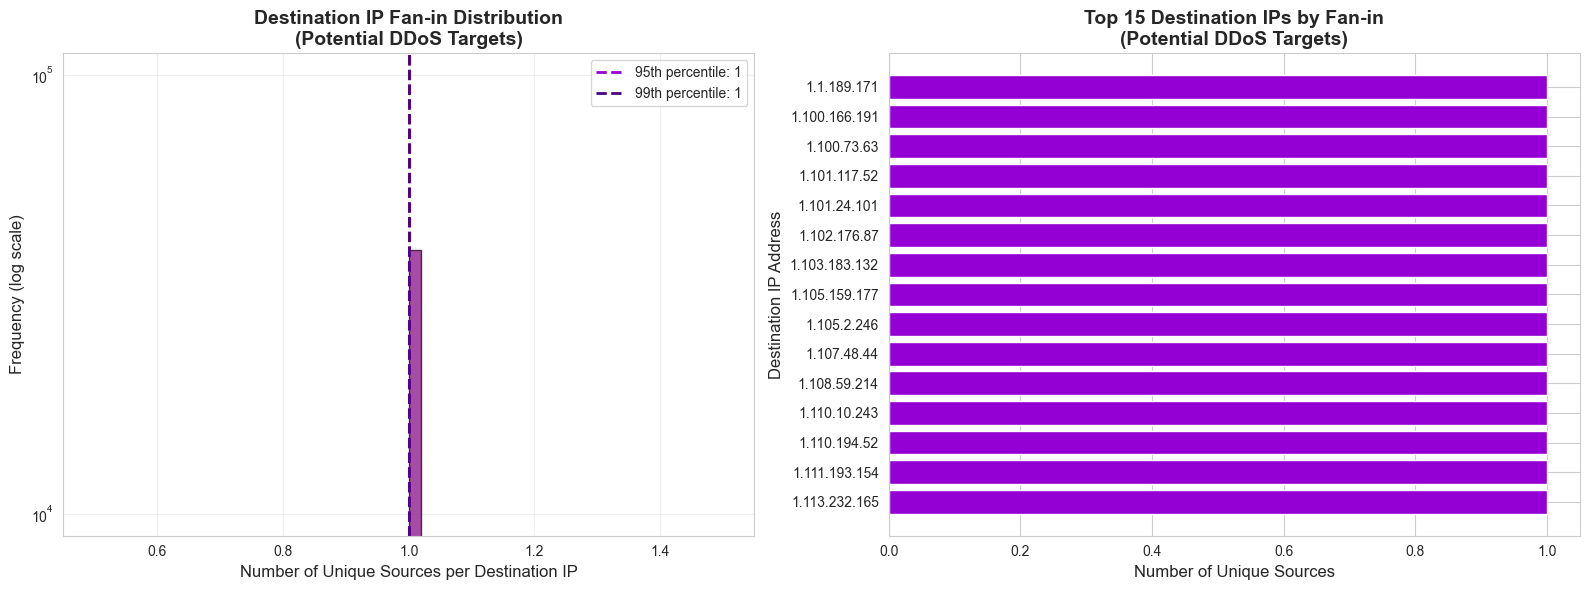

In [18]:
# Visualize fan-in distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
axes[0].hist(dst_to_src_mapping.values, bins=50, color='purple', alpha=0.7, edgecolor='black')
axes[0].axvline(threshold_95_dst, color='darkviolet', linestyle='--', linewidth=2, 
                label=f'95th percentile: {threshold_95_dst:.0f}')
axes[0].axvline(threshold_99_dst, color='indigo', linestyle='--', linewidth=2, 
                label=f'99th percentile: {threshold_99_dst:.0f}')
axes[0].set_xlabel('Number of Unique Sources per Destination IP', fontsize=12)
axes[0].set_ylabel('Frequency (log scale)', fontsize=12)
axes[0].set_title('Destination IP Fan-in Distribution\n(Potential DDoS Targets)', 
                  fontsize=14, fontweight='bold')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Top targeted IPs
top_targets = dst_to_src_mapping.head(15)
axes[1].barh(range(len(top_targets)), top_targets.values, color='darkviolet')
axes[1].set_yticks(range(len(top_targets)))
axes[1].set_yticklabels(top_targets.index)
axes[1].set_xlabel('Number of Unique Sources', fontsize=12)
axes[1].set_ylabel('Destination IP Address', fontsize=12)
axes[1].set_title('Top 15 Destination IPs by Fan-in\n(Potential DDoS Targets)', 
                  fontsize=14, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [19]:
# SPOOFING DETECTION 3: Bidirectional Traffic Analysis
print("\n" + "="*80)
print("SPOOFING INDICATOR 3: BIDIRECTIONAL TRAFFIC")
print("="*80)

source_ips_set = set(df['Source IP Address'].dropna())
dest_ips_set = set(df['Destination IP Address'].dropna())
bidirectional_ips = source_ips_set.intersection(dest_ips_set)

print(f"\nBidirectional IP Statistics:")
print(f"  - Total unique source IPs: {len(source_ips_set):,}")
print(f"  - Total unique destination IPs: {len(dest_ips_set):,}")
print(f"  - IPs appearing as BOTH source and destination: {len(bidirectional_ips):,}")
print(f"  - Percentage of bidirectional IPs: {len(bidirectional_ips)/(len(source_ips_set.union(dest_ips_set)))*100:.2f}%")

# Analyze bidirectional traffic by attack type
if 'Attack Type' in df.columns:
    df['is_bidirectional'] = (df['Source IP Address'].isin(bidirectional_ips)) | \
                              (df['Destination IP Address'].isin(bidirectional_ips))
    
    print(f"\nBidirectional Traffic by Attack Type:")
    bidir_attack = pd.crosstab(df['Attack Type'], df['is_bidirectional'], normalize='index') * 100
    print(bidir_attack)


SPOOFING INDICATOR 3: BIDIRECTIONAL TRAFFIC

Bidirectional IP Statistics:
  - Total unique source IPs: 40,000
  - Total unique destination IPs: 40,000
  - IPs appearing as BOTH source and destination: 1
  - Percentage of bidirectional IPs: 0.00%

Bidirectional Traffic by Attack Type:
is_bidirectional       False     True 
Attack Type                           
DDoS               99.992553  0.007447
Intrusion          99.992461  0.007539
Malware           100.000000  0.000000


In [63]:
df

,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Payload Data,...,has_proxy,is_bidirectional,src_is_private,dst_is_private,packet_length_bin,dst_port_category,src_port_category,anomaly_category,src_ip_class,dst_ip_class
0,2023-05-30 06:33:58,103.216.15.12,84.9.164.252,31225,17616,ICMP,503,Data,HTTP,Qui natus odio asperiores nam. Optio nobis ius...,...,1,False,False,False,256-512,Registered (1024-49151),Registered (1024-49151),Medium (25-50%),103,84
1,2020-08-26 07:08:30,78.199.217.198,66.191.137.154,17245,48166,ICMP,1174,Data,HTTP,Aperiam quos modi officiis veritatis rem. Omni...,...,0,False,False,False,1024-2048,Registered (1024-49151),Registered (1024-49151),High (50-75%),78,66
2,2022-11-13 08:23:25,63.79.210.48,198.219.82.17,16811,53600,UDP,306,Control,HTTP,Perferendis sapiente vitae soluta. Hic delectu...,...,1,False,False,False,256-512,Dynamic (49152-65535),Registered (1024-49151),Critical (75-100%),63,198
3,2023-07-02 10:38:46,163.42.196.10,101.228.192.255,20018,32534,UDP,385,Data,HTTP,Totam maxime beatae expedita explicabo porro l...,...,0,False,False,False,256-512,Registered (1024-49151),Registered (1024-49151),Low (0-25%),163,101
4,2023-07-16 13:11:07,71.166.185.76,189.243.174.238,6131,26646,TCP,1462,Data,DNS,Odit nesciunt dolorem nisi iste iusto. Animi v...,...,1,False,False,False,1024-2048,Registered (1024-49151),Registered (1024-49151),Low (0-25%),71,189
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,2023-05-26 14:08:42,26.36.109.26,121.100.75.240,31005,6764,UDP,1428,Control,HTTP,Quibusdam ullam consequatur consequuntur accus...,...,0,False,False,False,1024-2048,Registered (1024-49151),Registered (1024-49151),Medium (25-50%),26,121
39996,2023-03-27 00:38:27,17.21.163.81,196.108.134.78,2553,28091,UDP,1184,Control,HTTP,Quaerat neque esse. Animi expedita natus commo...,...,1,False,False,False,1024-2048,Registered (1024-49151),Registered (1024-49151),Medium (25-50%),17,196
39997,2022-03-31 01:45:49,162.35.217.57,98.107.0.15,22505,25152,UDP,1043,Data,DNS,Enim at aspernatur illum. Saepe numquam eligen...,...,0,False,False,False,1024-2048,Registered (1024-49151),Registered (1024-49151),Medium (25-50%),162,98
39998,2023-09-22 18:32:38,208.72.233.205,173.79.112.252,20013,2703,UDP,483,Data,FTP,Officiis dolorem sed harum provident earum dis...,...,1,False,False,False,256-512,Registered (1024-49151),Registered (1024-49151),Critical (75-100%),208,173


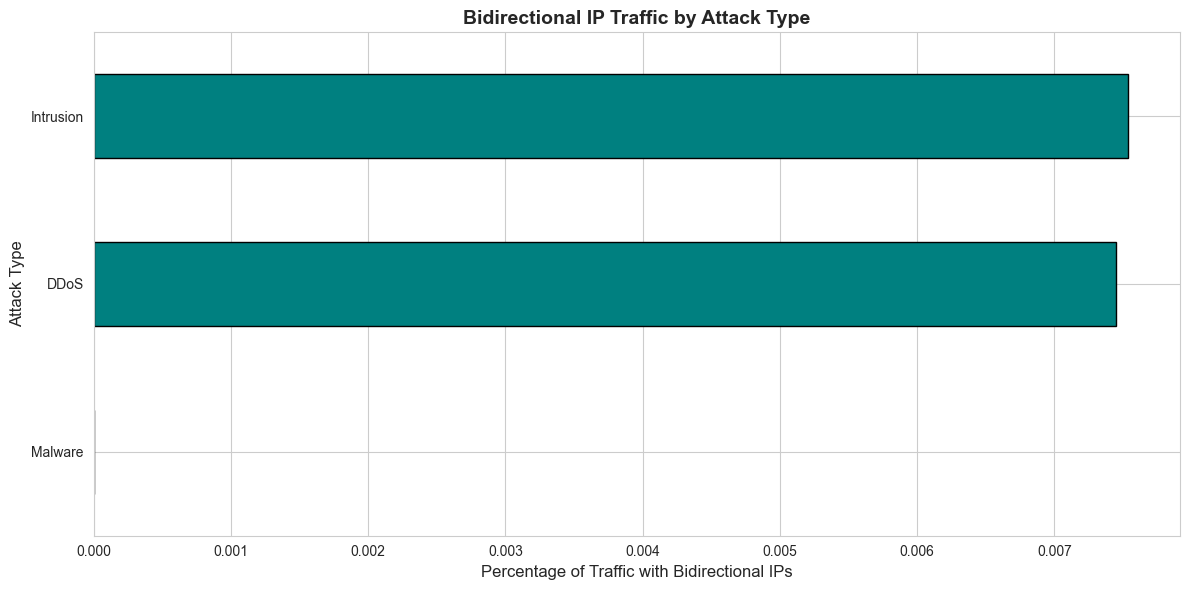

In [20]:
# Visualize bidirectional traffic
if 'Attack Type' in df.columns and 'is_bidirectional' in df.columns:
    plt.figure(figsize=(12, 6))
    bidir_attack[True].sort_values().plot(kind='barh', color='teal', edgecolor='black')
    plt.xlabel('Percentage of Traffic with Bidirectional IPs', fontsize=12)
    plt.ylabel('Attack Type', fontsize=12)
    plt.title('Bidirectional IP Traffic by Attack Type', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [21]:
# SPOOFING DETECTION 4: Private IP Detection
print("\n" + "="*80)
print("SPOOFING INDICATOR 4: PRIVATE IP ADDRESS DETECTION")
print("="*80)

def is_private_ip(ip):
    """Check if an IP is in private range (RFC 1918)"""
    if pd.isna(ip):
        return False
    try:
        parts = str(ip).split('.')
        if len(parts) != 4:
            return False
        first = int(parts[0])
        second = int(parts[1])
        
        # Private IP ranges: 10.x.x.x, 172.16-31.x.x, 192.168.x.x
        if first == 10:
            return True
        if first == 172 and 16 <= second <= 31:
            return True
        if first == 192 and second == 168:
            return True
        return False
    except:
        return False

df['src_is_private'] = df['Source IP Address'].apply(is_private_ip)
df['dst_is_private'] = df['Destination IP Address'].apply(is_private_ip)

print(f"\nPrivate IP Statistics:")
print(f"  - Source IPs from private ranges: {df['src_is_private'].sum():,} ({df['src_is_private'].sum()/len(df)*100:.2f}%)")
print(f"  - Destination IPs from private ranges: {df['dst_is_private'].sum():,} ({df['dst_is_private'].sum()/len(df)*100:.2f}%)")
print(f"  - Total connections involving private IPs: {(df['src_is_private'] | df['dst_is_private']).sum():,}")


SPOOFING INDICATOR 4: PRIVATE IP ADDRESS DETECTION

Private IP Statistics:
  - Source IPs from private ranges: 181 (0.45%)
  - Destination IPs from private ranges: 174 (0.43%)
  - Total connections involving private IPs: 355



Private IP Usage by Attack Type:
             Src_Private_Count  Src_Private_Pct  Dst_Private_Count  \
Attack Type                                                          
DDoS                        56         0.417039                 68   
Intrusion                   58         0.437241                 49   
Malware                     67         0.503494                 57   

             Dst_Private_Pct  
Attack Type                   
DDoS                0.506405  
Intrusion           0.369393  
Malware             0.428346  


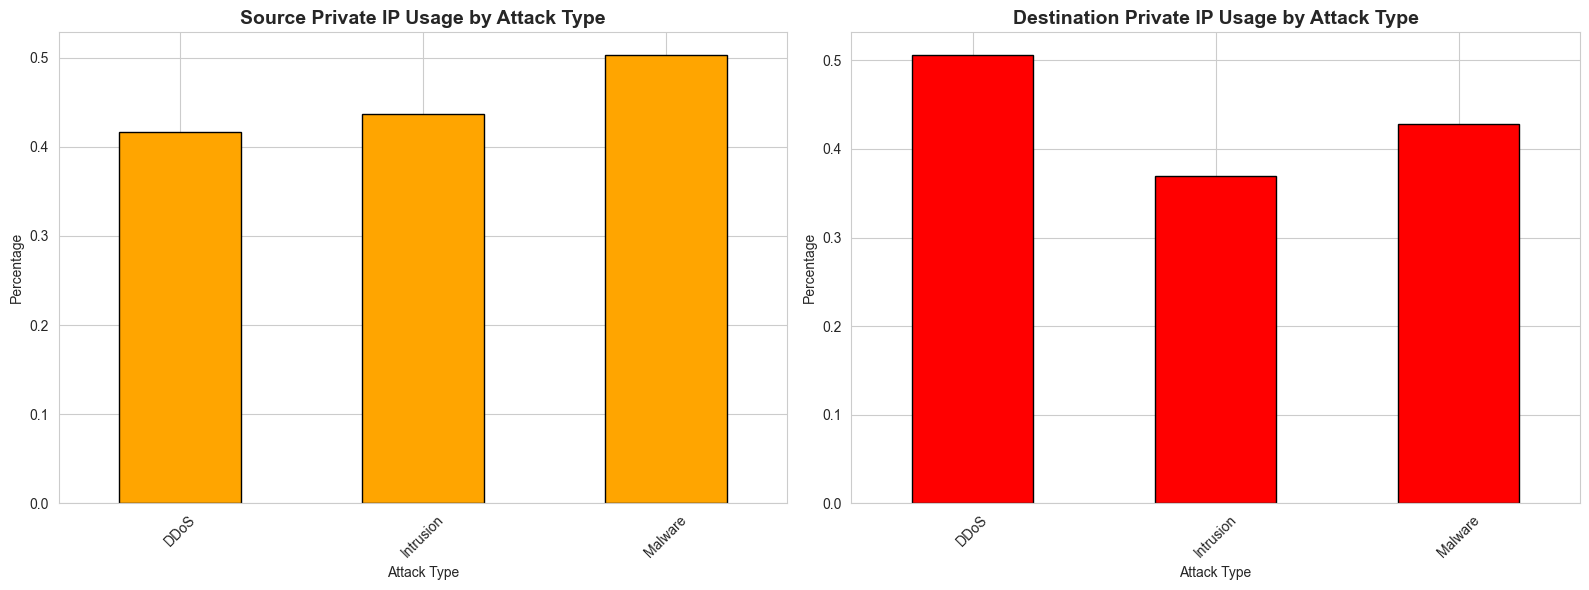

In [22]:
# Analyze private IP usage by attack type
if 'Attack Type' in df.columns:
    print("\nPrivate IP Usage by Attack Type:")
    attack_private = df.groupby('Attack Type').agg({
        'src_is_private': ['sum', 'mean'],
        'dst_is_private': ['sum', 'mean']
    })
    attack_private.columns = ['Src_Private_Count', 'Src_Private_Pct', 'Dst_Private_Count', 'Dst_Private_Pct']
    attack_private['Src_Private_Pct'] = attack_private['Src_Private_Pct'] * 100
    attack_private['Dst_Private_Pct'] = attack_private['Dst_Private_Pct'] * 100
    print(attack_private)
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    attack_private['Src_Private_Pct'].plot(kind='bar', ax=axes[0], color='orange', edgecolor='black')
    axes[0].set_title('Source Private IP Usage by Attack Type', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Attack Type')
    axes[0].set_ylabel('Percentage')
    axes[0].tick_params(axis='x', rotation=45)
    
    attack_private['Dst_Private_Pct'].plot(kind='bar', ax=axes[1], color='red', edgecolor='black')
    axes[1].set_title('Destination Private IP Usage by Attack Type', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Attack Type')
    axes[1].set_ylabel('Percentage')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

In [38]:
# 1. Check if this is time-series data (same IPs at different times)
temporal_reuse = df.groupby('Source IP Address')['Timestamp'].nunique()
print("IPs appearing at multiple timestamps:", (temporal_reuse > 1).sum())

# 2. Analyze if Source and Destination IPs ever overlap
src_set = set(df['Source IP Address'])
dst_set = set(df['Destination IP Address'])
overlap = src_set.intersection(dst_set)
print(f"IPs in both source and dest: {len(overlap)}")  # You found only 1!

# 3. Check distribution of IP ranges
df['src_ip_class'] = df['Source IP Address'].str.split('.').str[0].astype(int)
df['dst_ip_class'] = df['Destination IP Address'].str.split('.').str[0].astype(int)
print(df['src_ip_class'].value_counts())


IPs appearing at multiple timestamps: 0
IPs in both source and dest: 1
src_ip_class
46     222
146    212
166    211
118    209
63     208
      ... 
29     151
95     151
149    147
223    145
100    140
Name: count, Length: 222, dtype: int64


In [41]:
# 1. Check if proxy usage correlates with OTHER features instead
correlation_analysis = df.groupby('has_proxy').agg({
    'Packet Length': 'mean',
    'Anomaly Scores': 'mean',
    'Severity Level': lambda x: (x == 'Critical').mean()
})
print(correlation_analysis)

# 2. Test independence with chi-square
from scipy.stats import chi2_contingency
contingency = pd.crosstab(df['Attack Type'], df['has_proxy'])
chi2, p_value, dof, expected = chi2_contingency(contingency)
print(f"Chi-square p-value: {p_value}")
# If p > 0.05, proxy and attack type are independent

# 3. Analyze proxy usage with geo-location
proxy_geo = df.groupby('Geo-location Data')['has_proxy'].mean().sort_values(ascending=False).head(20)
print("Locations with highest proxy usage:")
print(proxy_geo)

           Packet Length  Anomaly Scores  Severity Level
has_proxy                                               
0             782.875926       50.086917             0.0
1             780.050573       50.139637             0.0
Chi-square p-value: 0.17083792384904176
Locations with highest proxy usage:
Geo-location Data
Yamunanagar, Andhra Pradesh     1.0
Agartala, Tamil Nadu            1.0
Adoni, Manipur                  1.0
Adoni, Andhra Pradesh           1.0
Yamunanagar, Tamil Nadu         1.0
Yamunanagar, Rajasthan          1.0
Adoni, Meghalaya                1.0
Adoni, Nagaland                 1.0
Buxar, Odisha                   1.0
Siwan, Karnataka                1.0
Sirsa, Tamil Nadu               1.0
Sirsa, Sikkim                   1.0
Sirsa, Meghalaya                1.0
Bulandshahr, Punjab             1.0
Sirsa, Karnataka                1.0
Chandigarh, Maharashtra         1.0
Chandigarh, Jharkhand           1.0
Chandigarh, Himachal Pradesh    1.0
Medininagar, Odisha           

In [47]:
# ANALYSIS 1: IP CLASS DISTRIBUTION AND ATTACK PATTERNS
# ============================================================================

def analyze_ip_class_patterns(df):
    """
    Analyze if certain IP ranges are associated with specific attack types
    """
    print("="*80)
    print("IP CLASS DISTRIBUTION ANALYSIS")
    print("="*80)
    
    

In [49]:
# Extract IP class (first octet)
df['src_ip_class'] = df['Source IP Address'].str.split('.').str[0].astype(int)
df['dst_ip_class'] = df['Destination IP Address'].str.split('.').str[0].astype(int)

    
# Source IP class distribution
print("\n1. Source IP Class Distribution:")
src_class_dist = df['src_ip_class'].value_counts().sort_index()
print(f"   - Total unique first octets: {len(src_class_dist)}")
print(f"   - Min IPs per class: {src_class_dist.min()}")
print(f"   - Max IPs per class: {src_class_dist.max()}")
print(f"   - Mean IPs per class: {src_class_dist.mean():.2f}")
print(f"   - Std dev: {src_class_dist.std():.2f}")
    


1. Source IP Class Distribution:
   - Total unique first octets: 222
   - Min IPs per class: 140
   - Max IPs per class: 222
   - Mean IPs per class: 180.18
   - Std dev: 14.36



2. IP Class vs Attack Type Association:

   IP Class 46 (n=222):
     - Dominant attack: Intrusion (37.4%)
     - Distribution: {'Intrusion': 83, 'Malware': 71, 'DDoS': 68}

   IP Class 146 (n=212):
     - Dominant attack: DDoS (36.8%)
     - Distribution: {'DDoS': 78, 'Malware': 68, 'Intrusion': 66}

   IP Class 166 (n=211):
     - Dominant attack: Malware (34.1%)
     - Distribution: {'Malware': 72, 'DDoS': 72, 'Intrusion': 67}

   IP Class 118 (n=209):
     - Dominant attack: Malware (36.4%)
     - Distribution: {'Malware': 76, 'Intrusion': 73, 'DDoS': 60}

   IP Class 63 (n=208):
     - Dominant attack: Malware (37.0%)
     - Distribution: {'Malware': 77, 'DDoS': 67, 'Intrusion': 64}

   IP Class 176 (n=208):
     - Dominant attack: DDoS (37.0%)
     - Distribution: {'DDoS': 77, 'Intrusion': 68, 'Malware': 63}

   IP Class 67 (n=207):
     - Dominant attack: Intrusion (37.7%)
     - Distribution: {'Intrusion': 78, 'Malware': 65, 'DDoS': 64}

   IP Class 68 (n=206):
     - Dominant

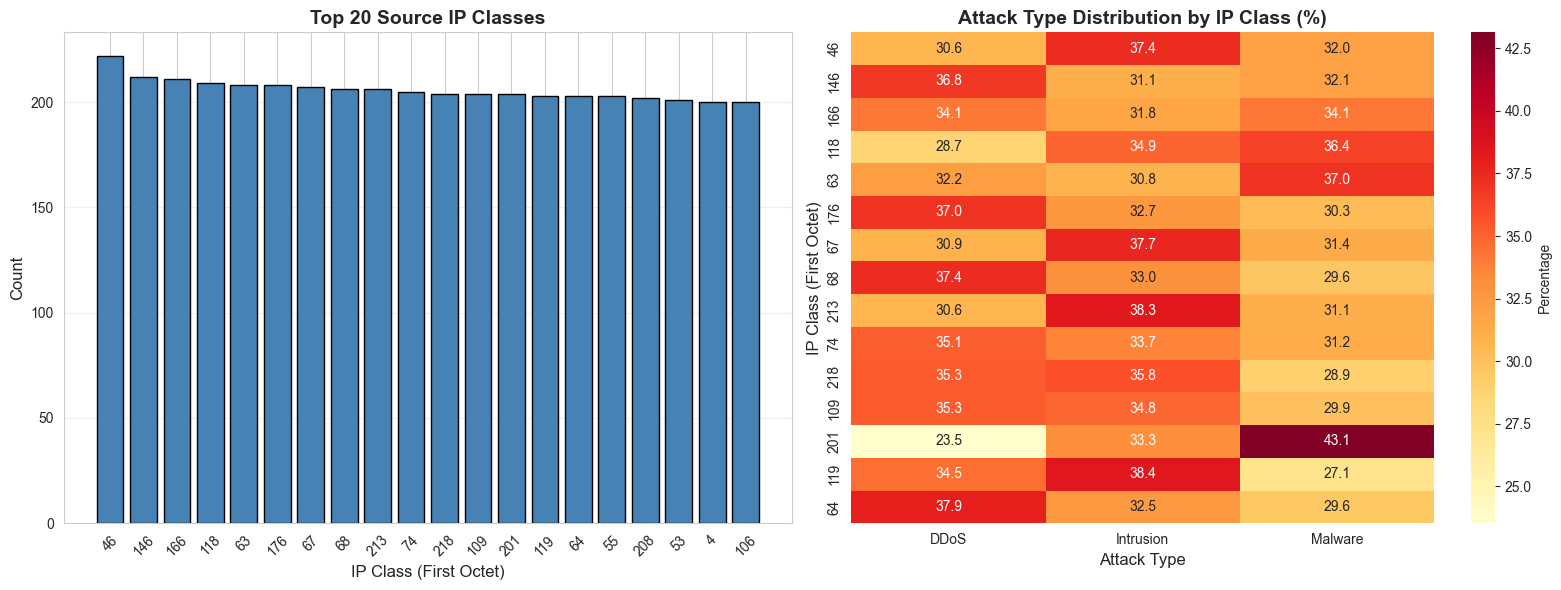


✓ Visualization saved as 'ip_class_analysis.png'


In [50]:
# Check if certain IP classes are associated with specific attacks
if 'Attack Type' in df.columns:
    print("\n2. IP Class vs Attack Type Association:")
        
# Get top 10 most common source IP classes
top_10_classes = df['src_ip_class'].value_counts().head(10).index
        
for ip_class in top_10_classes:
    subset = df[df['src_ip_class'] == ip_class]
    attack_dist = subset['Attack Type'].value_counts()
    dominant_attack = attack_dist.index[0]
    dominant_pct = (attack_dist.values[0] / len(subset)) * 100
            
    print(f"\n   IP Class {ip_class} (n={len(subset)}):")
    print(f"     - Dominant attack: {dominant_attack} ({dominant_pct:.1f}%)")
    print(f"     - Distribution: {attack_dist.to_dict()}")
            
# Check if this is significantly different from overall distribution
if dominant_pct > 40:  # If >40% is one type
    print(f"     ⚠️  PATTERN DETECTED: {ip_class}.x.x.x specializes in {dominant_attack}")
    
# Visualize IP class distribution by attack type
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
# Source IP class distribution
top_20_src_classes = df['src_ip_class'].value_counts().head(20)
axes[0].bar(range(len(top_20_src_classes)), top_20_src_classes.values, 
                color='steelblue', edgecolor='black')
axes[0].set_xticks(range(len(top_20_src_classes)))
axes[0].set_xticklabels(top_20_src_classes.index, rotation=45)
axes[0].set_xlabel('IP Class (First Octet)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Top 20 Source IP Classes', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
    
# IP class vs attack type heatmap
if 'Attack Type' in df.columns:
        ip_attack_matrix = pd.crosstab(
            df['src_ip_class'], 
            df['Attack Type'], 
            normalize='index'
        ) * 100
        
# Get top 15 IP classes for readability
top_15_classes = df['src_ip_class'].value_counts().head(15).index
ip_attack_subset = ip_attack_matrix.loc[top_15_classes]
        
sns.heatmap(ip_attack_subset, annot=True, fmt='.1f', cmap='YlOrRd', 
    ax=axes[1], cbar_kws={'label': 'Percentage'})
axes[1].set_xlabel('Attack Type', fontsize=12)
axes[1].set_ylabel('IP Class (First Octet)', fontsize=12)
axes[1].set_title('Attack Type Distribution by IP Class (%)', 
                         fontsize=14, fontweight='bold')
    
plt.tight_layout()
plt.savefig('ip_class_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✓ Visualization saved as 'ip_class_analysis.png'")

In [51]:
# Check the actual values in Severity Level
print(df['Severity Level'].value_counts())
print(df['Severity Level'].unique())

# It might be categorical ('Low', 'Medium', 'High') not numeric
# Or it might all be zeros/NaN

Severity Level
Medium    13435
High      13382
Low       13183
Name: count, dtype: int64
['Low' 'Medium' 'High']



Protocol Usage by Attack Type (%):
Protocol          ICMP        TCP        UDP
Attack Type                                 
DDoS         33.571641  33.050343  33.378016
Intrusion    33.622314  33.147380  33.230305
Malware      33.523709  33.343353  33.132938


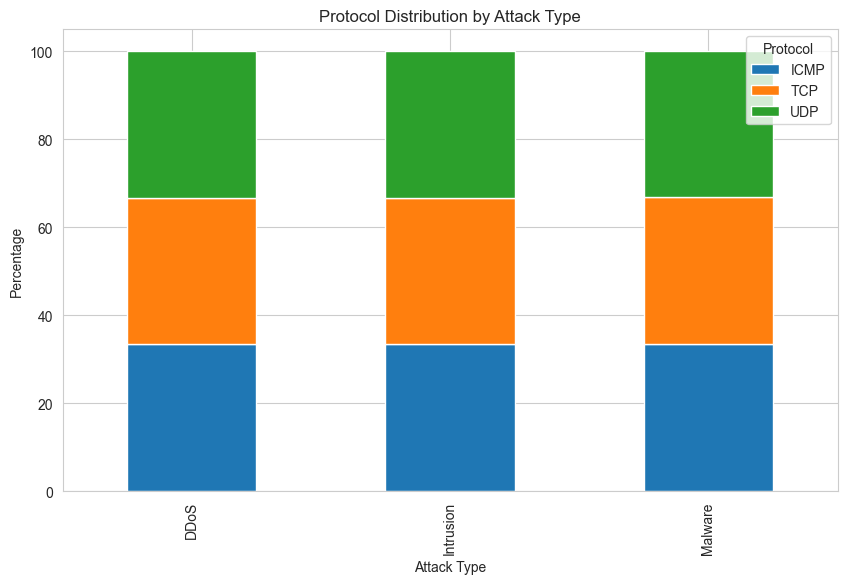

In [53]:
protocol_attack = pd.crosstab(df['Attack Type'], df['Protocol'], normalize='index') * 100
print("\nProtocol Usage by Attack Type (%):")
print(protocol_attack)

# Visualize
protocol_attack.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Protocol Distribution by Attack Type')
plt.ylabel('Percentage')
plt.legend(title='Protocol')
plt.show()


Packet Length ANOVA: F=1.05, p=3.5168e-01


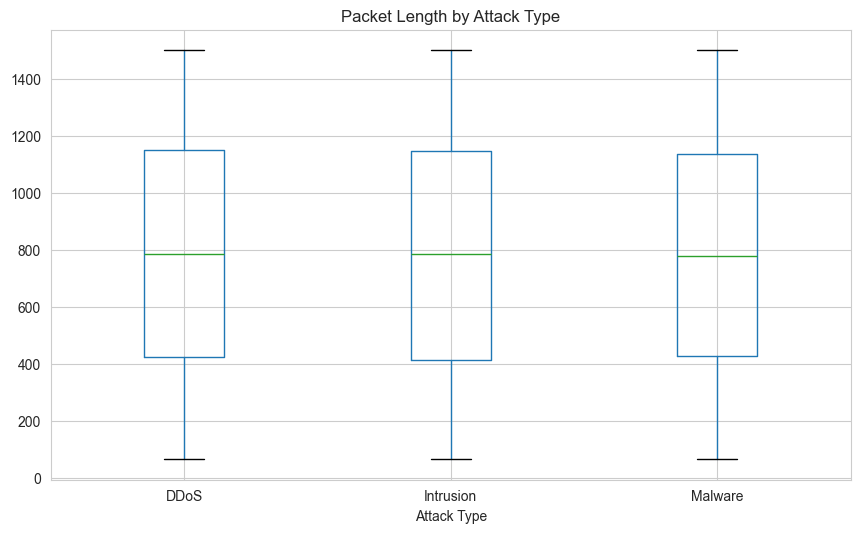

In [54]:
# Statistical test
from scipy.stats import f_oneway

ddos_packets = df[df['Attack Type'] == 'DDoS']['Packet Length']
malware_packets = df[df['Attack Type'] == 'Malware']['Packet Length']
intrusion_packets = df[df['Attack Type'] == 'Intrusion']['Packet Length']

f_stat, p_value = f_oneway(ddos_packets, malware_packets, intrusion_packets)
print(f"\nPacket Length ANOVA: F={f_stat:.2f}, p={p_value:.4e}")

if p_value < 0.001:
    print("✓ Packet Length is HIGHLY discriminative!")
    
# Show distributions
df.boxplot(column='Packet Length', by='Attack Type', figsize=(10, 6))
plt.title('Packet Length by Attack Type')
plt.suptitle('')
plt.show()

In [55]:
print("\nTop 10 Destination Ports by Attack Type:")

for attack in df['Attack Type'].unique():
    print(f"\n{attack}:")
    top_ports = df[df['Attack Type'] == attack]['Destination Port'].value_counts().head(10)
    for port, count in top_ports.items():
        pct = (count / len(df[df['Attack Type'] == attack])) * 100
        print(f"  Port {port}: {count} times ({pct:.1f}%)")


Top 10 Destination Ports by Attack Type:

Malware:
  Port 17890: 4 times (0.0%)
  Port 15559: 4 times (0.0%)
  Port 41043: 4 times (0.0%)
  Port 17896: 4 times (0.0%)
  Port 50417: 4 times (0.0%)
  Port 8226: 4 times (0.0%)
  Port 7550: 3 times (0.0%)
  Port 14719: 3 times (0.0%)
  Port 24994: 3 times (0.0%)
  Port 62717: 3 times (0.0%)

DDoS:
  Port 25319: 4 times (0.0%)
  Port 45110: 3 times (0.0%)
  Port 37758: 3 times (0.0%)
  Port 9565: 3 times (0.0%)
  Port 38472: 3 times (0.0%)
  Port 46157: 3 times (0.0%)
  Port 56552: 3 times (0.0%)
  Port 41588: 3 times (0.0%)
  Port 23924: 3 times (0.0%)
  Port 4523: 3 times (0.0%)

Intrusion:
  Port 33573: 4 times (0.0%)
  Port 22269: 4 times (0.0%)
  Port 14648: 4 times (0.0%)
  Port 18787: 4 times (0.0%)
  Port 5048: 4 times (0.0%)
  Port 12194: 3 times (0.0%)
  Port 33177: 3 times (0.0%)
  Port 54203: 3 times (0.0%)
  Port 19110: 3 times (0.0%)
  Port 51094: 3 times (0.0%)


In [56]:
severity_attack = pd.crosstab(df['Attack Type'], df['Severity Level'], normalize='index') * 100
print("\nSeverity Distribution by Attack Type (%):")
print(severity_attack)

# Chi-square test
from scipy.stats import chi2_contingency
contingency = pd.crosstab(df['Attack Type'], df['Severity Level'])
chi2, p_value, dof, expected = chi2_contingency(contingency)
print(f"\nChi-square: {chi2:.2f}, p-value: {p_value:.4e}")

if p_value < 0.05:
    print("✓ Severity is DEPENDENT on attack type")
else:
    print("✗ Severity is INDEPENDENT of attack type")


Severity Distribution by Attack Type (%):
Severity Level       High        Low     Medium
Attack Type                                    
DDoS            33.683348  33.139708  33.176944
Intrusion       33.373539  32.973992  33.652469
Malware         33.305779  32.757195  33.937026

Chi-square: 1.80, p-value: 7.7301e-01
✗ Severity is INDEPENDENT of attack type


In [57]:

from scipy.stats import f_oneway

ddos_anomaly = df[df['Attack Type'] == 'DDoS']['Anomaly Scores']
malware_anomaly = df[df['Attack Type'] == 'Malware']['Anomaly Scores']
intrusion_anomaly = df[df['Attack Type'] == 'Intrusion']['Anomaly Scores']

f_stat, p_value = f_oneway(ddos_anomaly, malware_anomaly, intrusion_anomaly)
print(f"Anomaly Scores ANOVA: F={f_stat:.2f}, p={p_value:.4e}")


print("\nMean Anomaly Scores:")
print(df.groupby('Attack Type')['Anomaly Scores'].mean())

Anomaly Scores ANOVA: F=0.27, p=7.6600e-01

Mean Anomaly Scores:
Attack Type
DDoS         50.235063
Intrusion    49.978029
Malware      50.125794
Name: Anomaly Scores, dtype: float64



GEO-LOCATION ANALYSIS

Geo-location Statistics:
  - Unique locations: 8,723
  - Missing values: 0

Top 15 Geo-locations:
Geo-location Data
Ghaziabad, Meghalaya                       16
Kalyan-Dombivli, Jharkhand                 15
Ghaziabad, Uttarakhand                     14
Ghaziabad, Tripura                         14
Motihari, Odisha                           13
Srikakulam, Uttarakhand                    13
Yamunanagar, Arunachal Pradesh             13
Kottayam, Nagaland                         13
Ghaziabad, Jharkhand                       13
Aurangabad, Nagaland                       13
Amroha, Sikkim                             13
Raurkela Industrial Township, Jharkhand    12
Patna, Karnataka                           12
Ghaziabad, Nagaland                        12
Bally, Maharashtra                         12
Name: count, dtype: int64


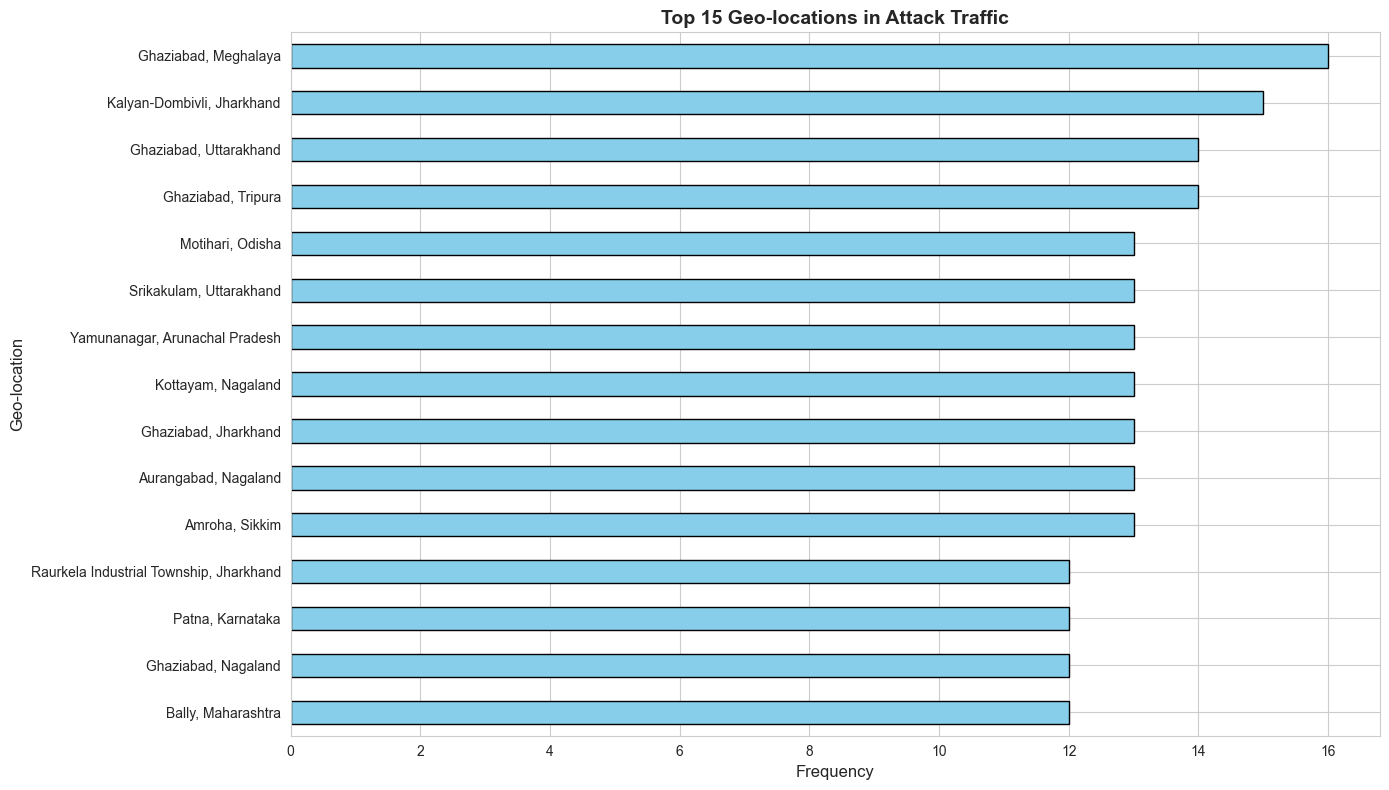


Top Geo-location by Attack Type:
  Malware: Aligarh, Chhattisgarh (9 occurrences)
  DDoS: Raichur, Sikkim (7 occurrences)
  Intrusion: Ghaziabad, Jharkhand (10 occurrences)


In [23]:
# Geo-location analysis (if available)
if 'Geo-location Data' in df.columns:
    print("\n" + "="*80)
    print("GEO-LOCATION ANALYSIS")
    print("="*80)
    
    print(f"\nGeo-location Statistics:")
    print(f"  - Unique locations: {df['Geo-location Data'].nunique():,}")
    print(f"  - Missing values: {df['Geo-location Data'].isna().sum():,}")
    
    # Top locations
    print(f"\nTop 15 Geo-locations:")
    top_locations = df['Geo-location Data'].value_counts().head(15)
    print(top_locations)
    
    # Visualize
    plt.figure(figsize=(14, 8))
    top_locations.plot(kind='barh', color='skyblue', edgecolor='black')
    plt.xlabel('Frequency', fontsize=12)
    plt.ylabel('Geo-location', fontsize=12)
    plt.title('Top 15 Geo-locations in Attack Traffic', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    # Geo-location by attack type
    if 'Attack Type' in df.columns:
        print(f"\nTop Geo-location by Attack Type:")
        for attack in df['Attack Type'].unique():
            top_loc = df[df['Attack Type'] == attack]['Geo-location Data'].value_counts().head(1)
            if len(top_loc) > 0:
                print(f"  {attack}: {top_loc.index[0]} ({top_loc.values[0]} occurrences)")

---
## 4. PART 3: Data Bin Trends Analysis

In [24]:
print("="*80)
print("DATA BIN TRENDS ANALYSIS")
print("="*80)

DATA BIN TRENDS ANALYSIS


In [25]:
# 1. PACKET LENGTH ANALYSIS
print("\n" + "="*80)
print("PACKET LENGTH DISTRIBUTION")
print("="*80)

if 'Packet Length' in df.columns:
    packet_lengths = df['Packet Length'].dropna()
    
    print(f"\nPacket Length Statistics:")
    print(f"  - Mean: {packet_lengths.mean():.2f} bytes")
    print(f"  - Median: {packet_lengths.median():.2f} bytes")
    print(f"  - Std Dev: {packet_lengths.std():.2f} bytes")
    print(f"  - Min: {packet_lengths.min():.2f} bytes")
    print(f"  - Max: {packet_lengths.max():.2f} bytes")
    print(f"  - 25th percentile: {packet_lengths.quantile(0.25):.2f} bytes")
    print(f"  - 75th percentile: {packet_lengths.quantile(0.75):.2f} bytes")


PACKET LENGTH DISTRIBUTION

Packet Length Statistics:
  - Mean: 781.45 bytes
  - Median: 782.00 bytes
  - Std Dev: 416.04 bytes
  - Min: 64.00 bytes
  - Max: 1500.00 bytes
  - 25th percentile: 420.00 bytes
  - 75th percentile: 1143.00 bytes


In [26]:
# Create packet length bins
bins_packet = [0, 64, 128, 256, 512, 1024, 2048, float('inf')]
labels_packet = ['0-64', '64-128', '128-256', '256-512', '512-1024', '1024-2048', '2048+']
df['packet_length_bin'] = pd.cut(df['Packet Length'], bins=bins_packet, labels=labels_packet)

packet_bin_dist = df['packet_length_bin'].value_counts().sort_index()
print(f"\nPacket Length Bins Distribution:")
print(packet_bin_dist)
print(f"\nPercentage Distribution:")
print((packet_bin_dist / packet_bin_dist.sum() * 100).round(2))


Packet Length Bins Distribution:
packet_length_bin
0-64            33
64-128        1861
128-256       3513
256-512       7143
512-1024     14168
1024-2048    13282
2048+            0
Name: count, dtype: int64

Percentage Distribution:
packet_length_bin
0-64          0.08
64-128        4.65
128-256       8.78
256-512      17.86
512-1024     35.42
1024-2048    33.20
2048+         0.00
Name: count, dtype: float64


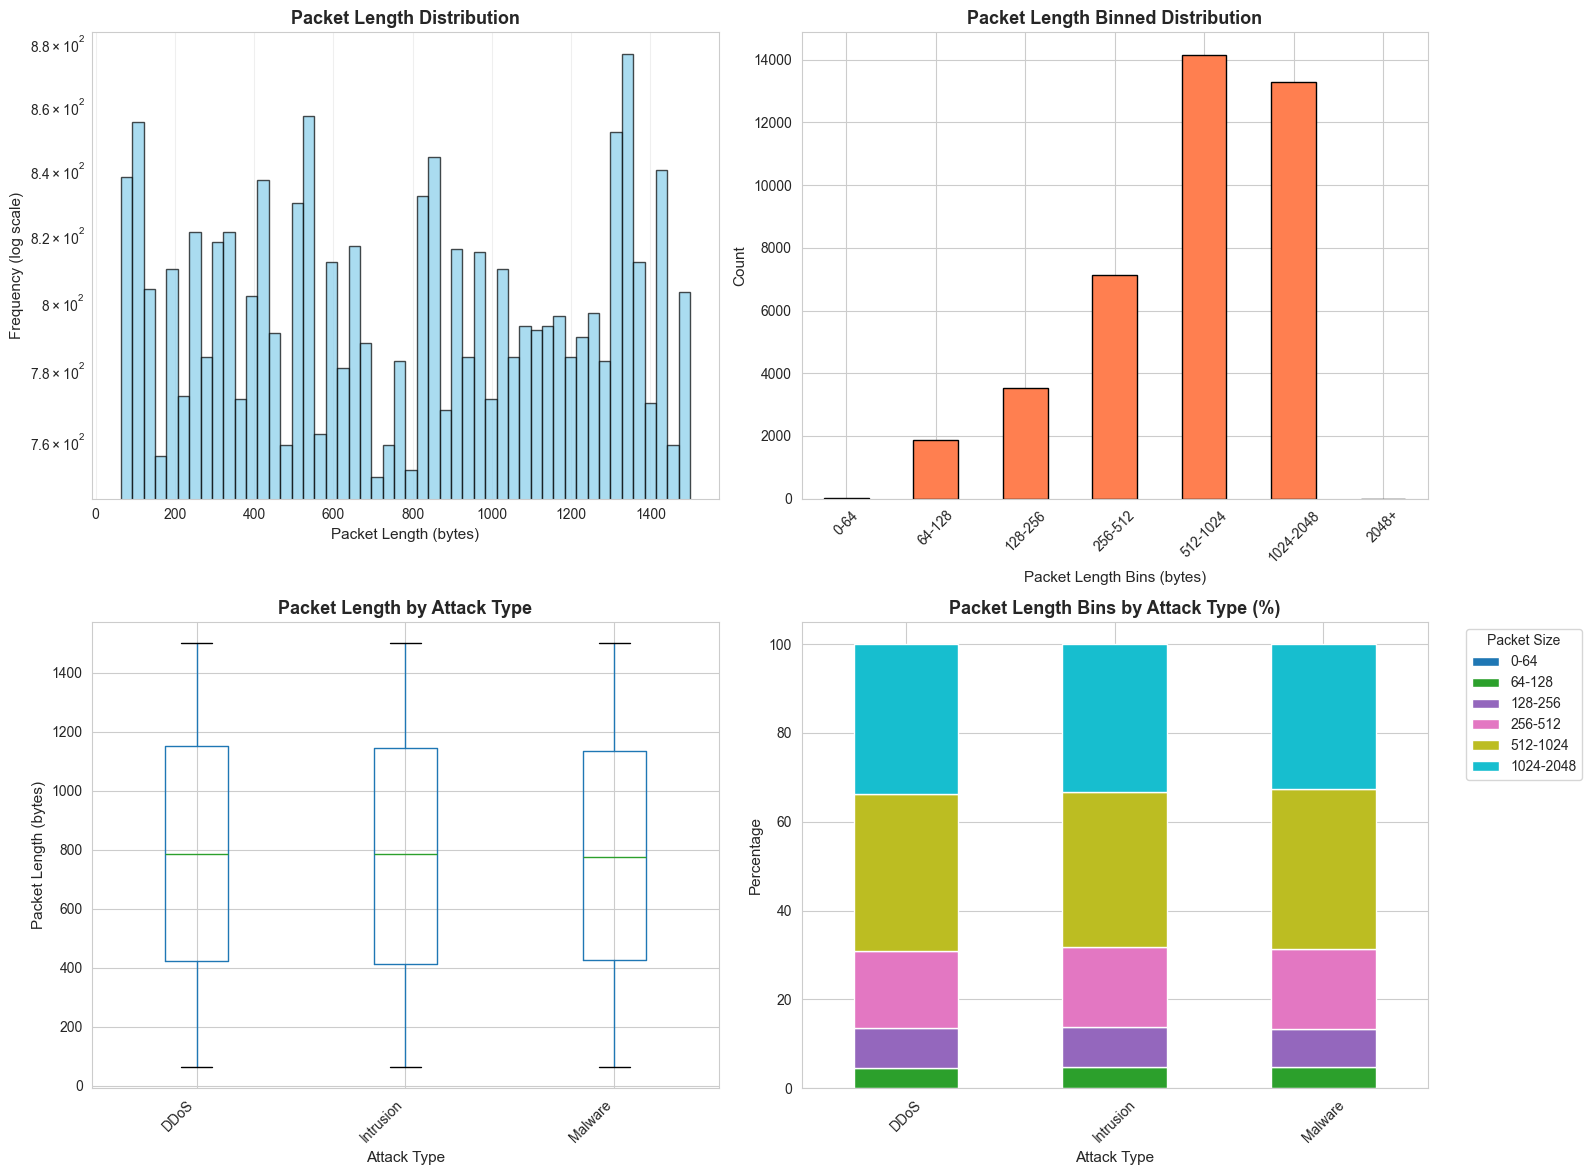

In [27]:
# Visualize packet length
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Histogram
axes[0, 0].hist(packet_lengths, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Packet Length (bytes)', fontsize=11)
axes[0, 0].set_ylabel('Frequency (log scale)', fontsize=11)
axes[0, 0].set_title('Packet Length Distribution', fontsize=13, fontweight='bold')
axes[0, 0].set_yscale('log')
axes[0, 0].grid(True, alpha=0.3)

# Binned distribution
packet_bin_dist.plot(kind='bar', ax=axes[0, 1], color='coral', edgecolor='black')
axes[0, 1].set_xlabel('Packet Length Bins (bytes)', fontsize=11)
axes[0, 1].set_ylabel('Count', fontsize=11)
axes[0, 1].set_title('Packet Length Binned Distribution', fontsize=13, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)

# Box plot by attack type
if 'Attack Type' in df.columns:
    df.boxplot(column='Packet Length', by='Attack Type', ax=axes[1, 0])
    axes[1, 0].set_xlabel('Attack Type', fontsize=11)
    axes[1, 0].set_ylabel('Packet Length (bytes)', fontsize=11)
    axes[1, 0].set_title('Packet Length by Attack Type', fontsize=13, fontweight='bold')
    axes[1, 0].get_figure().suptitle('')  # Remove default title
    plt.sca(axes[1, 0])
    plt.xticks(rotation=45, ha='right')

# Bins by attack type (stacked bar)
if 'Attack Type' in df.columns:
    bin_attack = pd.crosstab(df['Attack Type'], df['packet_length_bin'], normalize='index') * 100
    bin_attack.plot(kind='bar', stacked=True, ax=axes[1, 1], colormap='tab10')
    axes[1, 1].set_xlabel('Attack Type', fontsize=11)
    axes[1, 1].set_ylabel('Percentage', fontsize=11)
    axes[1, 1].set_title('Packet Length Bins by Attack Type (%)', fontsize=13, fontweight='bold')
    axes[1, 1].legend(title='Packet Size', bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [28]:
# 2. PORT ANALYSIS
print("\n" + "="*80)
print("PORT USAGE ANALYSIS")
print("="*80)

if 'Source Port' in df.columns and 'Destination Port' in df.columns:
    # Source ports
    print(f"\nTop 10 Source Ports:")
    top_src_ports = df['Source Port'].value_counts().head(10)
    print(top_src_ports)
    
    # Destination ports
    print(f"\nTop 10 Destination Ports:")
    top_dst_ports = df['Destination Port'].value_counts().head(10)
    print(top_dst_ports)


PORT USAGE ANALYSIS

Top 10 Source Ports:
Source Port
41341    6
37135    5
4128     5
16784    5
4779     5
12179    5
34763    5
30175    5
49911    5
4622     5
Name: count, dtype: int64

Top 10 Destination Ports:
Destination Port
34117    6
7508     6
39887    5
59207    5
6871     5
38787    5
19250    5
34873    5
15150    5
12585    5
Name: count, dtype: int64


In [29]:
# Create port categories
def categorize_port(port):
    """Categorize ports into well-known, registered, or dynamic"""
    if pd.isna(port):
        return 'Unknown'
    try:
        port = int(port)
        if 0 <= port <= 1023:
            return 'Well-known (0-1023)'
        elif 1024 <= port <= 49151:
            return 'Registered (1024-49151)'
        elif 49152 <= port <= 65535:
            return 'Dynamic (49152-65535)'
        else:
            return 'Unknown'
    except:
        return 'Unknown'

df['dst_port_category'] = df['Destination Port'].apply(categorize_port)
df['src_port_category'] = df['Source Port'].apply(categorize_port)

print(f"\nDestination Port Categories:")
print(df['dst_port_category'].value_counts())
print(f"\nPercentage:")
print((df['dst_port_category'].value_counts() / len(df) * 100).round(2))


Destination Port Categories:
dst_port_category
Registered (1024-49151)    29926
Dynamic (49152-65535)      10074
Name: count, dtype: int64

Percentage:
dst_port_category
Registered (1024-49151)    74.82
Dynamic (49152-65535)      25.18
Name: count, dtype: float64


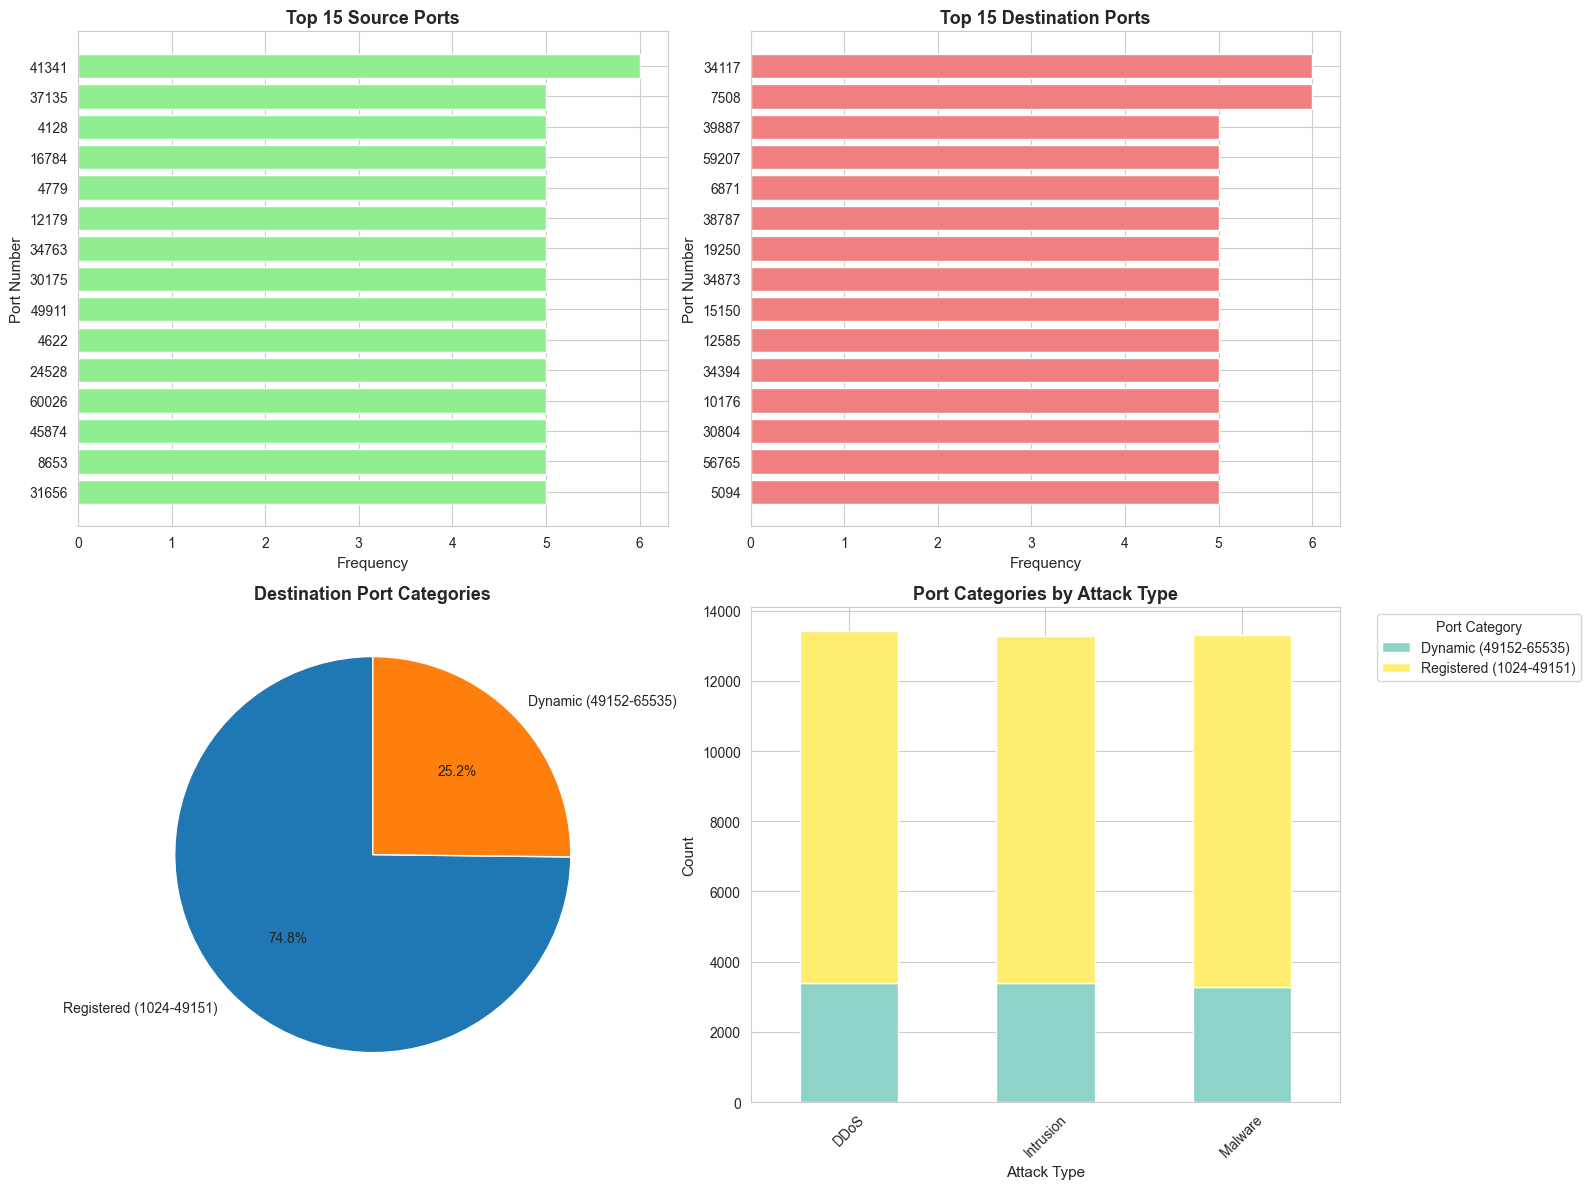

In [30]:
# Visualize port analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top source ports
top_src_ports_15 = df['Source Port'].value_counts().head(15)
axes[0, 0].barh(range(len(top_src_ports_15)), top_src_ports_15.values, color='lightgreen')
axes[0, 0].set_yticks(range(len(top_src_ports_15)))
axes[0, 0].set_yticklabels(top_src_ports_15.index)
axes[0, 0].set_xlabel('Frequency', fontsize=11)
axes[0, 0].set_ylabel('Port Number', fontsize=11)
axes[0, 0].set_title('Top 15 Source Ports', fontsize=13, fontweight='bold')
axes[0, 0].invert_yaxis()

# Top destination ports
top_dst_ports_15 = df['Destination Port'].value_counts().head(15)
axes[0, 1].barh(range(len(top_dst_ports_15)), top_dst_ports_15.values, color='lightcoral')
axes[0, 1].set_yticks(range(len(top_dst_ports_15)))
axes[0, 1].set_yticklabels(top_dst_ports_15.index)
axes[0, 1].set_xlabel('Frequency', fontsize=11)
axes[0, 1].set_ylabel('Port Number', fontsize=11)
axes[0, 1].set_title('Top 15 Destination Ports', fontsize=13, fontweight='bold')
axes[0, 1].invert_yaxis()

# Port category pie chart
port_cat_dist = df['dst_port_category'].value_counts()
axes[1, 0].pie(port_cat_dist.values, labels=port_cat_dist.index, autopct='%1.1f%%', startangle=90)
axes[1, 0].set_title('Destination Port Categories', fontsize=13, fontweight='bold')

# Port categories by attack type
if 'Attack Type' in df.columns:
    port_attack = pd.crosstab(df['Attack Type'], df['dst_port_category'])
    port_attack.plot(kind='bar', stacked=True, ax=axes[1, 1], colormap='Set3')
    axes[1, 1].set_xlabel('Attack Type', fontsize=11)
    axes[1, 1].set_ylabel('Count', fontsize=11)
    axes[1, 1].set_title('Port Categories by Attack Type', fontsize=13, fontweight='bold')
    axes[1, 1].legend(title='Port Category', bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [31]:
# 3. PROTOCOL ANALYSIS
print("\n" + "="*80)
print("PROTOCOL DISTRIBUTION")
print("="*80)

if 'Protocol' in df.columns:
    protocol_dist = df['Protocol'].value_counts()
    print(f"\nProtocol Distribution:")
    print(protocol_dist)
    print(f"\nPercentage:")
    print((protocol_dist / protocol_dist.sum() * 100).round(2))


PROTOCOL DISTRIBUTION

Protocol Distribution:
Protocol
ICMP    13429
UDP     13299
TCP     13272
Name: count, dtype: int64

Percentage:
Protocol
ICMP    33.57
UDP     33.25
TCP     33.18
Name: count, dtype: float64



Protocol Usage by Attack Type (%):
Protocol      ICMP    TCP    UDP
Attack Type                     
DDoS         33.57  33.05  33.38
Intrusion    33.62  33.15  33.23
Malware      33.52  33.34  33.13


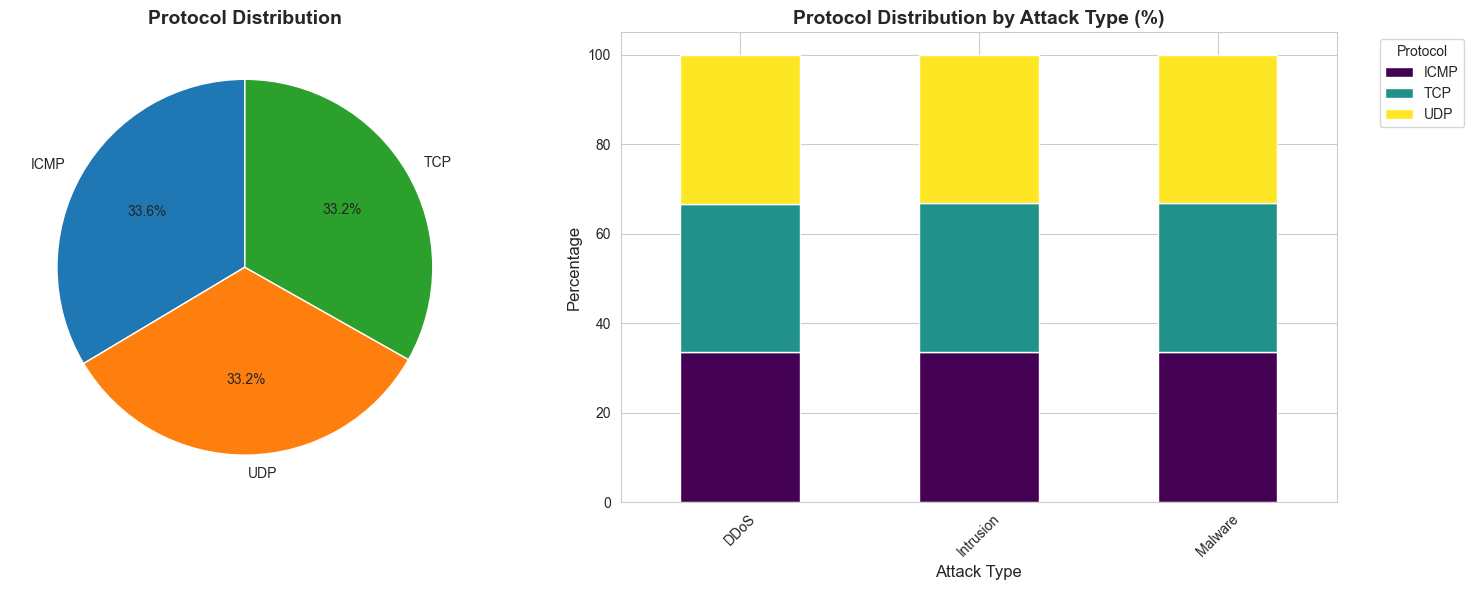

In [32]:
# Visualize protocol analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Protocol pie chart
axes[0].pie(protocol_dist.values, labels=protocol_dist.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Protocol Distribution', fontsize=14, fontweight='bold')

# Protocol by attack type
if 'Attack Type' in df.columns:
    protocol_attack = pd.crosstab(df['Attack Type'], df['Protocol'], normalize='index') * 100
    protocol_attack.plot(kind='bar', stacked=True, ax=axes[1], colormap='viridis')
    axes[1].set_xlabel('Attack Type', fontsize=12)
    axes[1].set_ylabel('Percentage', fontsize=12)
    axes[1].set_title('Protocol Distribution by Attack Type (%)', fontsize=14, fontweight='bold')
    axes[1].legend(title='Protocol', bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[1].tick_params(axis='x', rotation=45)
    
    print(f"\nProtocol Usage by Attack Type (%):")
    print(protocol_attack.round(2))

plt.tight_layout()
plt.show()

In [33]:
# 4. ANOMALY SCORES ANALYSIS
print("\n" + "="*80)
print("ANOMALY SCORES DISTRIBUTION")
print("="*80)

if 'Anomaly Scores' in df.columns:
    anomaly_scores = df['Anomaly Scores'].dropna()
    
    print(f"\nAnomaly Score Statistics:")
    print(f"  - Mean: {anomaly_scores.mean():.4f}")
    print(f"  - Median: {anomaly_scores.median():.4f}")
    print(f"  - Std Dev: {anomaly_scores.std():.4f}")
    print(f"  - Min: {anomaly_scores.min():.4f}")
    print(f"  - Max: {anomaly_scores.max():.4f}")
    print(f"  - 25th percentile: {anomaly_scores.quantile(0.25):.4f}")
    print(f"  - 50th percentile: {anomaly_scores.quantile(0.50):.4f}")
    print(f"  - 75th percentile: {anomaly_scores.quantile(0.75):.4f}")


ANOMALY SCORES DISTRIBUTION

Anomaly Score Statistics:
  - Mean: 50.1135
  - Median: 50.3450
  - Std Dev: 28.8536
  - Min: 0.0000
  - Max: 100.0000
  - 25th percentile: 25.1500
  - 50th percentile: 50.3450
  - 75th percentile: 75.0300


In [34]:
# Create anomaly score categories based on quartiles
anomaly_bins = [anomaly_scores.min(), 
                anomaly_scores.quantile(0.25),
                anomaly_scores.quantile(0.5),
                anomaly_scores.quantile(0.75),
                anomaly_scores.max()]
anomaly_labels = ['Low (0-25%)', 'Medium (25-50%)', 'High (50-75%)', 'Critical (75-100%)']

df['anomaly_category'] = pd.cut(df['Anomaly Scores'], bins=anomaly_bins, 
                                 labels=anomaly_labels, include_lowest=True)

anomaly_cat_dist = df['anomaly_category'].value_counts().sort_index()
print(f"\nAnomaly Score Categories:")
print(anomaly_cat_dist)
print(f"\nPercentage:")
print((anomaly_cat_dist / anomaly_cat_dist.sum() * 100).round(2))


Anomaly Score Categories:
anomaly_category
Low (0-25%)           10004
Medium (25-50%)        9996
High (50-75%)         10001
Critical (75-100%)     9999
Name: count, dtype: int64

Percentage:
anomaly_category
Low (0-25%)           25.01
Medium (25-50%)       24.99
High (50-75%)         25.00
Critical (75-100%)    25.00
Name: count, dtype: float64


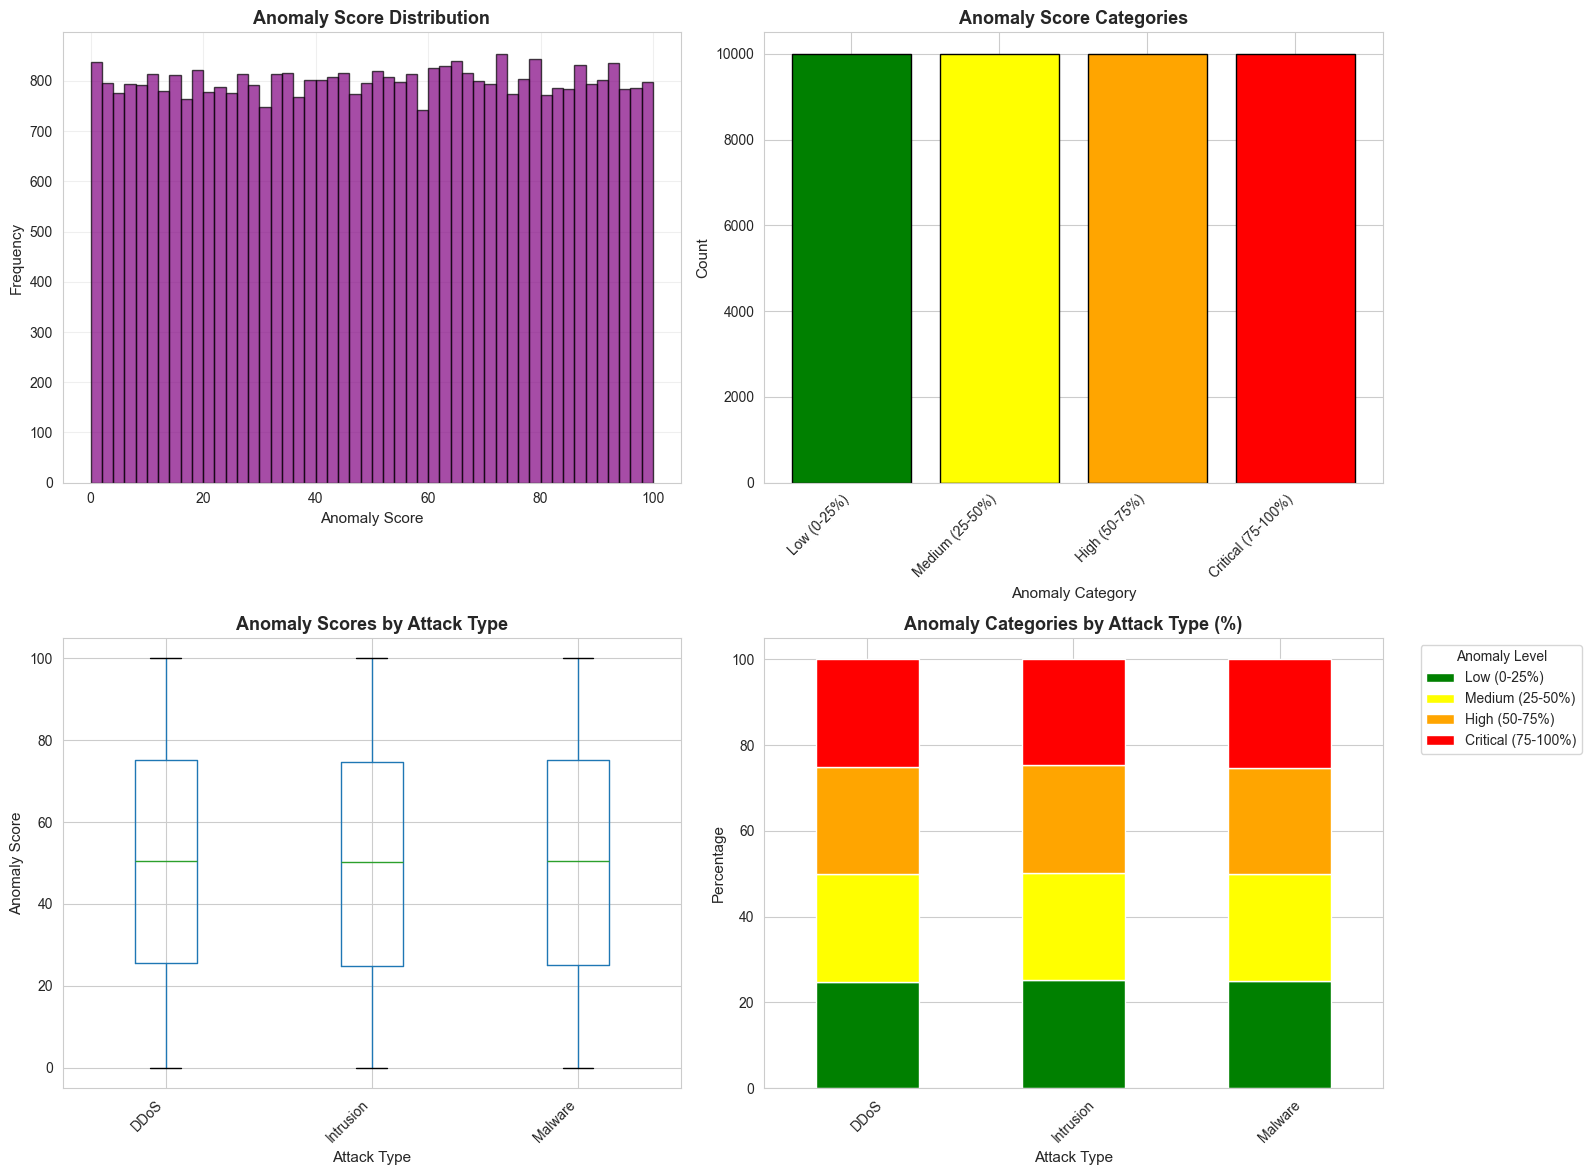

In [35]:
# Visualize anomaly scores
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Histogram
axes[0, 0].hist(anomaly_scores, bins=50, color='purple', alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Anomaly Score', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Anomaly Score Distribution', fontsize=13, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Category bar chart
colors = ['green', 'yellow', 'orange', 'red']
axes[0, 1].bar(range(len(anomaly_cat_dist)), anomaly_cat_dist.values, 
               color=colors, edgecolor='black')
axes[0, 1].set_xticks(range(len(anomaly_cat_dist)))
axes[0, 1].set_xticklabels(anomaly_cat_dist.index, rotation=45, ha='right')
axes[0, 1].set_xlabel('Anomaly Category', fontsize=11)
axes[0, 1].set_ylabel('Count', fontsize=11)
axes[0, 1].set_title('Anomaly Score Categories', fontsize=13, fontweight='bold')

# Box plot by attack type
if 'Attack Type' in df.columns:
    df.boxplot(column='Anomaly Scores', by='Attack Type', ax=axes[1, 0])
    axes[1, 0].set_xlabel('Attack Type', fontsize=11)
    axes[1, 0].set_ylabel('Anomaly Score', fontsize=11)
    axes[1, 0].set_title('Anomaly Scores by Attack Type', fontsize=13, fontweight='bold')
    axes[1, 0].get_figure().suptitle('')
    plt.sca(axes[1, 0])
    plt.xticks(rotation=45, ha='right')

# Category by attack type
if 'Attack Type' in df.columns:
    anomaly_attack = pd.crosstab(df['Attack Type'], df['anomaly_category'], normalize='index') * 100
    anomaly_attack.plot(kind='bar', stacked=True, ax=axes[1, 1], color=colors)
    axes[1, 1].set_xlabel('Attack Type', fontsize=11)
    axes[1, 1].set_ylabel('Percentage', fontsize=11)
    axes[1, 1].set_title('Anomaly Categories by Attack Type (%)', fontsize=13, fontweight='bold')
    axes[1, 1].legend(title='Anomaly Level', bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
## 5. COMPREHENSIVE SUMMARY & INSIGHTS

In [58]:
print("\n" + "="*80)
print("COMPREHENSIVE EDA SUMMARY")
print("="*80)

print(f"\n📊 DATASET OVERVIEW")
print("-" * 80)
print(f"Total Records: {len(df):,}")
print(f"Total Features: {df.shape[1]}")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

if 'Attack Type' in df.columns:
    print(f"\n🎯 ATTACK TYPE DISTRIBUTION")
    print("-" * 80)
    attack_dist = df['Attack Type'].value_counts()
    for attack, count in attack_dist.items():
        print(f"  {attack}: {count:,} ({count/len(df)*100:.2f}%)")

print(f"\n🔍 KEY STATISTICS")
print("-" * 80)

# Proxy
if 'has_proxy' in df.columns:
    proxy_pct = (df['has_proxy'].sum() / len(df)) * 100
    print(f"  - Proxy Usage Rate: {proxy_pct:.2f}%")

# IPs
if 'Source IP Address' in df.columns:
    print(f"  - Unique Source IPs: {df['Source IP Address'].nunique():,}")
    print(f"  - Unique Destination IPs: {df['Destination IP Address'].nunique():,}")

# Packet Length
if 'Packet Length' in df.columns:
    print(f"  - Average Packet Size: {df['Packet Length'].mean():.2f} bytes")

# Protocol
if 'Protocol' in df.columns:
    top_protocol = df['Protocol'].value_counts().index[0]
    top_protocol_pct = (df['Protocol'].value_counts().values[0] / len(df)) * 100
    print(f"  - Most Common Protocol: {top_protocol} ({top_protocol_pct:.2f}%)")

# Port
if 'Destination Port' in df.columns:
    top_port = df['Destination Port'].value_counts().index[0]
    top_port_count = df['Destination Port'].value_counts().values[0]
    print(f"  - Most Targeted Port: {top_port} ({top_port_count:,} times)")




COMPREHENSIVE EDA SUMMARY

📊 DATASET OVERVIEW
--------------------------------------------------------------------------------
Total Records: 40,000
Total Features: 35
Memory Usage: 60.68 MB

🎯 ATTACK TYPE DISTRIBUTION
--------------------------------------------------------------------------------
  DDoS: 13,428 (33.57%)
  Malware: 13,307 (33.27%)
  Intrusion: 13,265 (33.16%)

🔍 KEY STATISTICS
--------------------------------------------------------------------------------
  - Proxy Usage Rate: 50.37%
  - Unique Source IPs: 40,000
  - Unique Destination IPs: 40,000
  - Average Packet Size: 781.45 bytes
  - Most Common Protocol: ICMP (33.57%)
  - Most Targeted Port: 34117 (6 times)
